In this notebook Seamese network model for handwriting author verification trained. As backbone CNN+crossViT with contrastive loss used. 

Let's import training dataset

In [1]:
#importing dataset
!pip install -q gdown

file_id = "1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl"
output_name = "all_data_3.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl
From (redirected): https://drive.google.com/uc?id=1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl&confirm=t&uuid=ce437584-cbe1-48c6-bc62-0179a0371ce5
To: /content/all_data_3.zip
100% 1.76G/1.76G [00:21<00:00, 84.0MB/s]


In [2]:
import zipfile
import os

with zipfile.ZipFile("all_data_3.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['all_data_3']

In [3]:
DATA_ROOT = "/kaggle/working/all_data_3"

Now importing val and test datasets in .pkl files.

In [4]:
val_dataset_file="1AUeTVTv7dkVVabhnNLEDEFg6FEDTLyx7"
output_name = "val_pairs.pkl"

!gdown --id {val_dataset_file} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1AUeTVTv7dkVVabhnNLEDEFg6FEDTLyx7
To: /content/val_pairs.pkl
100% 145k/145k [00:00<00:00, 86.0MB/s]


In [5]:
test_dataset_file="17eaXxFbrPBEg0qoVBHP3ryICsLJo9hIF"
output_name = "test_pairs.pkl"

!gdown --id {test_dataset_file} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=17eaXxFbrPBEg0qoVBHP3ryICsLJo9hIF
To: /content/test_pairs.pkl
100% 95.7k/95.7k [00:00<00:00, 103MB/s]


In [6]:
DATA_ROOT_val_pairs = "/kaggle/working/val_pairs.pkl"
DATA_ROOT_test_pairs = "/kaggle/working/test_pairs.pkl"

In [7]:
!pip install torchvision

In [8]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, LinearLR, CosineAnnealingLR, SequentialLR
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import timm
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix

from torchvision.utils import make_grid

from sklearn.manifold import TSNE

In [9]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


Let's create class SiameseNetworkDataset for our data.
The dataset takes random pairs and create either positive (one author) or negative pair. The labels are created at random, the balance shall be ~50/50.
The pairs are created 'on the fly'.

In [10]:
class Pairs_Dataset(Dataset):
    def __init__(self, root, transform=None, size=100,
                 authors_list=None, iam_ratio=0.5):
        """
        Dataset for Siamese Network with Contrastive Loss.
        Supports IAM (handwriting lines), CEDAR, Bengali, Hindi (signatures with forgeries).

        Args:
            root: Root directory containing 'iam', 'cedar', 'bengali', 'hindi' folders
            transform: Image transformations
            size: Number of pairs per epoch
            authors_list: List of author IDs to include (for train/val split)
            iam_ratio: Probability of sampling from IAM (0.5 = 50% IAM)
        """
        self.transform = transform
        self.size = size
        self.iam_ratio = iam_ratio

        # Data structures
        self.iam_data = {}
        self.cedar_original = {}
        self.cedar_forgery = {}
        self.bengali_original = {}
        self.bengali_forgery = {}
        self.hindi_original = {}
        self.hindi_forgery = {}

        # Scan IAM folder
        iam_path = os.path.join(root, 'iam')
        if os.path.exists(iam_path):
            for folder in os.listdir(iam_path):
                author_path = os.path.join(iam_path, folder)
                if not os.path.isdir(author_path):
                    continue

                author_id = folder
                valid_images = []
                for file in os.listdir(author_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue

                    img_path = os.path.join(author_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        valid_images.append(img_path)
                    except Exception:
                        continue

                if valid_images:
                    self.iam_data[author_id] = valid_images

        # Scan CEDAR folder
        cedar_path = os.path.join(root, 'cedar')
        if os.path.exists(cedar_path):
            cedar_original_path = os.path.join(cedar_path, 'original')
            if os.path.exists(cedar_original_path):
                for author_id in os.listdir(cedar_original_path):
                    author_path = os.path.join(cedar_original_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_original[author_id] = valid_images

            cedar_forgery_path = os.path.join(cedar_path, 'forgery')
            if os.path.exists(cedar_forgery_path):
                for author_id in os.listdir(cedar_forgery_path):
                    author_path = os.path.join(cedar_forgery_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_forgery[author_id] = valid_images

        # Scan Bengali folder
        bengali_path = os.path.join(root, 'bengali')
        if os.path.exists(bengali_path):
            for author_id in os.listdir(bengali_path):
                author_path = os.path.join(bengali_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_forgery[author_id] = valid_images

        # Scan Hindi folder
        hindi_path = os.path.join(root, 'hindi')
        if os.path.exists(hindi_path):
            for author_id in os.listdir(hindi_path):
                author_path = os.path.join(hindi_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_forgery[author_id] = valid_images

        # Filter by authors_list if provided
        if authors_list is not None:
            author_set = set(authors_list)
            self.iam_data = {k: v for k, v in self.iam_data.items() if k in author_set}
            self.cedar_original = {k: v for k, v in self.cedar_original.items() if k in author_set}
            self.cedar_forgery = {k: v for k, v in self.cedar_forgery.items() if k in author_set}
            self.bengali_original = {k: v for k, v in self.bengali_original.items() if k in author_set}
            self.bengali_forgery = {k: v for k, v in self.bengali_forgery.items() if k in author_set}
            self.hindi_original = {k: v for k, v in self.hindi_original.items() if k in author_set}
            self.hindi_forgery = {k: v for k, v in self.hindi_forgery.items() if k in author_set}

        # Build author lists
        self.iam_authors = [a for a, imgs in self.iam_data.items() if len(imgs) >= 2]
        self.iam_all_authors = list(self.iam_data.keys())

        def build_signature_lists(original_dict, forgery_dict):
            authors_with_original = [a for a, imgs in original_dict.items() if len(imgs) >= 2]
            authors_with_forgery = [a for a in original_dict.keys()
                                     if a in forgery_dict
                                     and len(original_dict[a]) >= 1
                                     and len(forgery_dict[a]) >= 1]
            all_authors = list(original_dict.keys())
            return authors_with_original, authors_with_forgery, all_authors

        self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors = build_signature_lists(self.cedar_original, self.cedar_forgery)
        self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors = build_signature_lists(self.bengali_original, self.bengali_forgery)
        self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors = build_signature_lists(self.hindi_original, self.hindi_forgery)

        # Combine signature datasets
        self.signature_datasets = []
        if self.cedar_authors or self.cedar_authors_with_forgery:
            self.signature_datasets.append(('cedar', self.cedar_original, self.cedar_forgery,
                                           self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors))
        if self.bengali_authors or self.bengali_authors_with_forgery:
            self.signature_datasets.append(('bengali', self.bengali_original, self.bengali_forgery,
                                           self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors))
        if self.hindi_authors or self.hindi_authors_with_forgery:
            self.signature_datasets.append(('hindi', self.hindi_original, self.hindi_forgery,
                                           self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors))


    def __len__(self):
        return self.size

    def _get_iam_pair(self, label):
        """IAM: positive=same author, negative=different authors"""
        if label == 1:
            if not self.iam_authors:
                return None, None, None
            author = random.choice(self.iam_authors)
            images = self.iam_data[author]
            if len(images) < 2:
                return None, None, None
            img1_path, img2_path = random.sample(images, 2)
        else:
            if len(self.iam_all_authors) < 2:
                return None, None, None
            author1, author2 = random.sample(self.iam_all_authors, 2)
            img1_path = random.choice(self.iam_data[author1])
            img2_path = random.choice(self.iam_data[author2])
        return img1_path, img2_path, label

    def _get_signature_pair(self, dataset_name, original_dict, forgery_dict,
                           authors, authors_with_forgery, all_authors, label):
        """
        Signature datasets (CEDAR, Bengali, Hindi):
        - Positive: 2 genuine signatures from the SAME author
        - Negative: 1 genuine + 1 forgery from the SAME author (ALWAYS hard negative)
        """
        if label == 1:
            # Positive: two genuine signatures from the same author
            if not authors:
                return None, None, None
            author = random.choice(authors)
            original_images = original_dict[author]
            if len(original_images) < 2:
                return None, None, None
            img1_path, img2_path = random.sample(original_images, 2)
        else:
            # Negative: original + forgery from the SAME author (ALWAYS hard negative)
            if not authors_with_forgery:
                return None, None, None
            author = random.choice(authors_with_forgery)
            original_images = original_dict[author]
            forgery_images = forgery_dict[author]
            if not original_images or not forgery_images:
                return None, None, None
            img1_path = random.choice(original_images)
            img2_path = random.choice(forgery_images)

        return img1_path, img2_path, label

    def __getitem__(self, idx):
        use_iam = random.random() < self.iam_ratio
        label = random.randint(0, 1)

        img1_path, img2_path, final_label = None, None, None

        if use_iam and self.iam_authors:
            img1_path, img2_path, final_label = self._get_iam_pair(label)

        if img1_path is None and self.signature_datasets:
            dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
            result = self._get_signature_pair(dataset_name, original_dict, forgery_dict,
                                              authors, authors_with_forgery, all_authors, label)
            img1_path, img2_path, final_label = result

        if img1_path is None:
            # Fallback: try any available dataset
            if self.iam_authors:
                img1_path, img2_path, final_label = self._get_iam_pair(1)
            elif self.signature_datasets:
                dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
                result = self._get_signature_pair(dataset_name, original_dict, forgery_dict,
                                                  authors, authors_with_forgery, all_authors, 1)
                img1_path, img2_path, final_label = result

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, final_label

In [11]:
train_authors=['353', '662', '546', '181', '126', '104', '15', '72', '629', '094', '10', '139', '090', '636', '160', '092', '136', '328', '190', '20', '392', '652',
               '5', '405', '378', '236', '650', '573', '162', '349', '515', '59', '128', '421', '48', '14', '3', '262', '454', '670', '281', '543', '435', '632', '393',
               '192', '594', '237', '270', '250', '153', '320', '6', '531', '418', '399', '460', '603', '027', '598', '276', '083', '216', '391', '131', '2', '496', '53',
               '618', '093', '318', '214', '189', '110', '425', '389', '420', '401', '32', '562', '170', '93', '609', '616', '357', '597', '80', '626', '332', '119', '060',
               '487', '025', '547', '390', '513', '147', '072', '553', '183', '623', '615', '500', '198', '011', '174', '647', '664', '278', '445', '290', '210', '272',
               '448', '503', '534', '69', '88', '68', '120', '24', '464', '398', '568', '070', '610', '628', '591', '31', '529', '215', '149', '138', '118', '451', '572',
               '17', '339', '049', '25', '60', '26', '243', '054', '032', '586', '471', '377', '342', '87', '58', '620', '179', '89', '109', '304', '034', '365', '373',
               '363', '169', '071', '49', '579', '382', '444', '412', '485', '310', '473', '619', '084', '518', '535', '144', '542', '280', '145', '520', '156', '099',
               '576', '570', '589', '059', '595', '208', '361', '307', '558', '101', '67', '030', '38', '115', '19', '371', '340', '567', '319', '352', '274', '530',
               '102', '259', '555', '525', '462', '226', '27', '539', '041', '607', '508', '344', '182', '79', '288', '085', '095', '239', '267', '584', '92', '639',
               '410', '70', '184', '121', '492', '114', '509', '053', '334', '246', '490', '449', '255', '440', '185', '580', '294', '477', '495', '436', '291', '641',
               '33', '35', '21', '089', '103', '289', '370', '221', '466', '242', '076', '423', '379', '020', '008', '224', '019', '248', '98', '067', '483', '37', '663',
               '064', '582', '086', '031', '23', '563', '611', '305', '96', '472', '283', '043', '414', '141', '34', '151', '065', '621', '55', '91', '260', '231', '048',
               '478', '499', '606', '056', '354', '229', '045', '81', '096', '343', '408', '264', '155', '596', '253', '461', '235', '042', '73', '347', '482', '475',
               '386', '197', '394', '431', '65', '634', '416', '90', '36', '303', '122', '018', '517', '668', '252', '097', '228', '107', '413', '082', '556', '203',
               '494', '285', '028', '191', '592', '256', '578', '171', '002', '188', '526', '367', '116', '522', '234', '71', '30', '035', '364', '268', '327', '484',
               '146', '312', '533', '4', '046', '209', '433', '86', '402', '350', '640', '428', '453', '279', '536', '441', '037', '614', '47', '296', '159', '315', '062',
               '000', '407', '549', '080', '335', '079', '504', '659', '419', '117', '540', '081', '452', '351', '521', '384', '051', '648', '524', '036', '411', '75',
               '645', '325', '559', '211', '583', '527', '1', '502', '447', '7', '193', '565', '99', '152', '551', '608', '403', '195', '298', '006', '004', '077',
               '187', '301', '491', '366', '130', '538', '206', '324', '175', '098', '247', '180', '222', '251', '28', '63', '474', '671', '545', '088', '052', '388',
               '257', '123', '172', '486', '83', '554', '41', '417', '430', '660', '023', '56', '380', '40', '227', '566', '026', '219', '481', '575', '309', '489', '638',
               '148', '45', '258', '249', '200', '356', '331', '263', '232', '630', '063', '164', '544', '168', '359', '443', '047', '186', '85', '470', '336', '176',
               '078', '651', '196', '577', '455', '012', '666', '571', '317', '376', '429', '655', '314', '52', '600', '058', '212', '016', '022', '217', '94', '106',
               '44', '244', '77', '199', '8', '329', '22', '519', '561', '643', '64', '137', '501', '493']
val_authors=['456', '9', '426', '97', '322', '133', '13', '021', '157', '355', '166', '375', '627', '345', '605', '140', '135', '161', '163', '593', '476', '84', '225',
             '223', '62', '213', '512', '266', '537', '446', '100', '346', '422', '233', '613', '167', '261', '360', '127', '633', '292', '442', '341', '564', '468',
             '654', '467', '302', '330', '220', '465', '458', '18', '299', '326', '286', '014', '528', '635', '007', '569', '548', '333', '57', '207', '581', '039',
             '50', '338', '439', '205', '54', '552', '173', '348', '644', '488', '665', '362', '498', '409', '637', '587', '075', '300', '108', '642', '74', '400',
             '76', '074', '125', '51', '091', '017', '295', '245', '624', '142', '383', '585', '457', '230', '040', '497', '073', '432', '369', '275', '506', '201',
             '241', '129', '218']
test_authors=['43', '134', '516', '055', '204', '313', '523', '068', '404', '372', '601', '395', '469', '617', '009', '254', '588', '194', '337', '178', '511', '29',
              '015', '82', '287', '124', '599', '112', '39', '541', '293', '010', '143', '625', '132', '95', '158', '649', '622', '316', '282', '667', '532', '321',
              '177', '013', '505', '297', '631', '42', '658', '66', '368', '202', '510', '590', '165', '459', '154', '434', '61', '005', '397', '105', '602', '265',
              '46', '396', '387', '450', '323', '001', '087', '240', '113', '066', '604', '044', '061', '550', '463', '653', '033', '273', '669', '514', '150', '024',
              '424', '479', '069', '16', '574', '308', '238', '038', '415', '560', '385', '557', '277', '480', '612', '661', '111', '12', '427', '78', '050', '003',
              '269', '11', '406', '029']


In [12]:
train_transform = T.Compose([
    T.Resize((240, 240)),  #use 240*240 for the model
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

val_transform = T.Compose([
    T.Resize((240, 240)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

test_transform = T.Compose([
    T.Resize((240, 240)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

In [13]:
train_dataset = Pairs_Dataset(
    root=DATA_ROOT,
    transform=train_transform,
    size=5000,
    authors_list=train_authors
)

In [14]:
class SavedPairsDataset(Dataset):
    def __init__(self, pairs_file, transform=None):
        with open(pairs_file, 'rb') as f:
            self.pairs = pickle.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

# # Создание и сохранение
# val_pairs = []
# test_pairs = []
# temp_dataset_val = Pairs_Dataset(root=DATA_ROOT, transform=None, 
#                               size=2000, authors_list=val_authors)
# temp_dataset_test = Pairs_Dataset(root=DATA_ROOT, transform=None, 
#                               size=1000, authors_list=test_authors)
# for i in range(len(temp_dataset_val)):
#     img1, img2, label, p1, p2 = temp_dataset_val[i]
#     val_pairs.append((p1, p2, label))

# for i in range(len(temp_dataset_test)):
#     img1, img2, label, p1, p2 = temp_dataset_test[i]
#     test_pairs.append((p1, p2, label))

# with open('val_pairs.pkl', 'wb') as f:
#     pickle.dump(val_pairs, f)

# with open('test_pairs.pkl', 'wb') as f:
#     pickle.dump(test_pairs, f)

# Загрузка
val_dataset = SavedPairsDataset('val_pairs.pkl', transform=val_transform)
test_dataset = SavedPairsDataset('test_pairs.pkl', transform=test_transform)

Label: 0
Size img1: torch.Size([1, 240, 240])
Size img2: torch.Size([1, 240, 240])


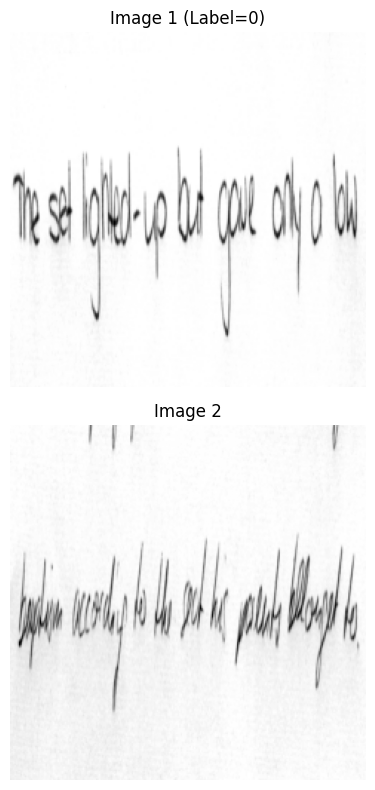

In [15]:
img1, img2, label = test_dataset[1]

print(f"Label: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
labels=[]

for i in range(len(train_dataset)):
  labels.append(train_dataset[i][2])

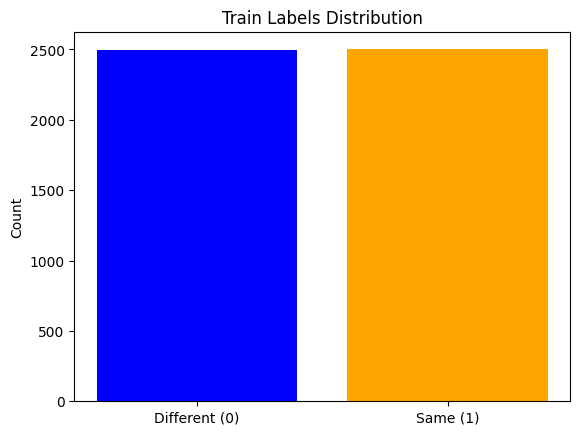

In [ ]:
counts = [labels.count(0), labels.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Train Labels Distribution')
plt.show()

In [16]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

This code implements a hybrid CNN-ViT model for contrastive learning (Siamese network architecture).

Architecture:

CNN Branch (ResNet-18): Extracts local features from grayscale images. Uses FPN (Feature Pyramid Network) to combine features from three ResNet layers (64, 128, 256 channels), projecting them to 128 channels each, then concatenating (128×3=384 dimensions).

CrossViT Branch: Processes the same image through a CrossViT Base 240 transformer adapted for grayscale input. Outputs 768-dimensional features.

Fusion Module: Concatenates CNN (384) and CrossViT (768) features → Linear(1152→512) → BatchNorm → ReLU → Dropout(0.3) → Linear(512→embedding_size) → BatchNorm → L2 normalization.

Key Features:

Grayscale adaptation: First Conv2d layers of both ResNet and CrossViT are adapted from 3 channels to 1 channel by averaging RGB weights.

Selective freezing (partial mode): Freezes early CNN layers (conv1, layer1, layer2) and early CrossViT transformer blocks, keeping only last 4 blocks trainable (12 total).

Forward method: Takes two images (x1, x2) and returns their L2-normalized embeddings for contrastive loss training.

Output: Normalized embeddings suitable for similarity comparison using Euclidean distance.

In [17]:
def adapt_conv2d_to_grayscale(module):
    if isinstance(module, nn.Conv2d) and module.in_channels == 3:
        new_conv = nn.Conv2d(
            1, module.out_channels,
            kernel_size=module.kernel_size,
            stride=module.stride,
            padding=module.padding,
            dilation=module.dilation,
            groups=module.groups,
            bias=module.bias is not None
        )
        with torch.no_grad():
            new_conv.weight.data = module.weight.data.mean(dim=1, keepdim=True)
            if module.bias is not None:
                new_conv.bias.data = module.bias.data
        module.in_channels = 1
        module.weight.data = new_conv.weight.data
        if module.bias is not None:
            module.bias.data = new_conv.bias.data
        return True
    return False


def adapt_model_to_grayscale(model):
    adapted_count = 0
    for module in model.modules():
        if adapt_conv2d_to_grayscale(module):
            adapted_count += 1
    return model


class CNNCrossViT(nn.Module):
    def __init__(self, embedding_size=256, pretrained=True, freeze_backbone='partial'):
        super(CNNCrossViT, self).__init__()

        #1. CNN BRANCH (ResNet-18)
        if pretrained:
            resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        else:
            resnet = resnet18(weights=None)

        original_conv1 = resnet.conv1
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            resnet.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)

        self.cnn_conv1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.cnn_layer1 = resnet.layer1
        self.cnn_layer2 = resnet.layer2
        self.cnn_layer3 = resnet.layer3

        # FPN
        self.fpn_lateral = nn.ModuleList([
            nn.Conv2d(64, 128, 1),
            nn.Conv2d(128, 128, 1),
            nn.Conv2d(256, 128, 1)
        ])
        self.fpn_output = nn.ModuleList([
            nn.Conv2d(128, 128, 3, padding=1),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.Conv2d(128, 128, 3, padding=1)
        ])

        #2. CROSSVIT BRANCH
        self.crossvit = timm.create_model('crossvit_base_240', pretrained=pretrained, num_classes=0)

        adapt_model_to_grayscale(self.crossvit)

        cnn_out_dim = 128 * 3
        crossvit_out_dim = self.crossvit.num_features

        #3. FUSION
        self.fusion = nn.Sequential(
            nn.Linear(cnn_out_dim + crossvit_out_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_size),
            nn.BatchNorm1d(embedding_size)
        )

        self.embedding_size = embedding_size

        #4. FREEZE LAYERS
        self._freeze_layers(freeze_backbone)

        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"CNN-CrossViT initialized. Embedding size: {embedding_size}")
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

    def _freeze_layers(self, freeze_mode):
        if freeze_mode == 'partial':
            # CNN Branch
            for param in self.cnn_conv1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer2.parameters():
                param.requires_grad = False

            # CrossViT Branch - freeze early transformer blocks
            self._freeze_crossvit_transformer_blocks(num_trainable_blocks=4)

        elif freeze_mode == 'full':
            # Freeze all CNN
            for param in self.cnn_conv1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer2.parameters():
                param.requires_grad = False
            for param in self.cnn_layer3.parameters():
                param.requires_grad = False

            # Freeze all CrossViT
            for param in self.crossvit.parameters():
                param.requires_grad = False

    def _freeze_crossvit_transformer_blocks(self, num_trainable_blocks=4):
        """
        Freeze CrossViT transformer blocks.
        Structure: blocks (3 MultiScaleBlock) → each has .blocks (4 transformer Block)
        Total: 12 transformer blocks
        """
        all_transformer_blocks = []

        # Collect all transformer blocks from all stages
        if hasattr(self.crossvit, 'blocks'):
            for stage_idx, multi_scale_block in enumerate(self.crossvit.blocks):
                if hasattr(multi_scale_block, 'blocks'):
                    for block_idx, transformer_block in enumerate(multi_scale_block.blocks):
                        all_transformer_blocks.append({
                            'stage': stage_idx,
                            'block': block_idx,
                            'module': transformer_block
                        })

        total_blocks = len(all_transformer_blocks)
        print(f"Found {total_blocks} transformer blocks in CrossViT")

        if total_blocks == 0:
            for param in self.crossvit.parameters():
                param.requires_grad = False
            return

        # Freeze all except last N blocks
        frozen_count = 0
        trainable_count = 0

        for i, block_info in enumerate(all_transformer_blocks):
            if i < total_blocks - num_trainable_blocks:
                for param in block_info['module'].parameters():
                    param.requires_grad = False
                frozen_count += 1
            else:
                trainable_count += 1

    def _fpn_forward(self, c1, c2, c3):
        p3 = self.fpn_lateral[2](c3)
        p2 = self.fpn_lateral[1](c2)
        p1 = self.fpn_lateral[0](c1)

        p2 = p2 + F.interpolate(p3, size=p2.shape[-2:], mode='nearest')
        p1 = p1 + F.interpolate(p2, size=p1.shape[-2:], mode='nearest')

        p3 = self.fpn_output[2](p3)
        p2 = self.fpn_output[1](p2)
        p1 = self.fpn_output[0](p1)

        p1 = F.adaptive_avg_pool2d(p1, 1).flatten(1)
        p2 = F.adaptive_avg_pool2d(p2, 1).flatten(1)
        p3 = F.adaptive_avg_pool2d(p3, 1).flatten(1)

        return torch.cat([p1, p2, p3], dim=1)

    def forward_one(self, x):
        c1 = self.cnn_conv1(x)
        c2 = self.cnn_layer1(c1)
        c3 = self.cnn_layer2(c2)
        c4 = self.cnn_layer3(c3)
        cnn_features = self._fpn_forward(c2, c3, c4)

        crossvit_features = self.crossvit(x)

        combined = torch.cat([cnn_features, crossvit_features], dim=1)
        embedding = self.fusion(combined)

        return F.normalize(embedding, p=2, dim=1)

    def forward(self, x1, x2):
        emb1 = self.forward_one(x1)
        emb2 = self.forward_one(x2)
        return emb1, emb2

Creating contrastive loss class

In [18]:
class ContrastiveLoss(nn.Module):
    """Contrastive loss"""

    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Eucledian distance
        distance = F.pairwise_distance(output1, output2)

        loss = label * torch.pow(distance, 2) / 2
        loss += (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2) / 2

        return loss.mean()

This function trains the CNN-CrossViT hybrid model for handwriting verification using contrastive loss (pairwise learning).

Training Setup:

Optimizer: AdamW with weight decay (0.01)

Learning Rate Schedule: 5 epochs warmup (linear from 1% to target LR) followed by cosine annealing to 1e-6

Loss Function: ContrastiveLoss with margin=1.0 (encourages same-author pairs to have small distance and different-author pairs to have large distance)

Key Metrics Tracked per Epoch:

Training: Loss, accuracy (using fixed threshold 0.5), ROC-AUC

Validation: Loss, accuracy (fixed threshold), ROC-AUC, EER (Equal Error Rate), best accuracy with optimal threshold (found by testing all unique distances)

Process Flow:

Forward pass through model to get embeddings for both images in a pair

Compute Euclidean distance between embeddings

Apply contrastive loss based on label (1 = same author, 0 = different authors)

Optimize and update learning rate scheduler

Evaluate on validation set, compute comprehensive metrics

Save checkpoint when validation ROC-AUC improves

History Returned:
Dictionary containing training curves: losses, accuracies, ROC-AUC scores, best accuracy, EER values, and learning rates for each epoch.

In [19]:
def calculate_eer(labels, scores):
    """
    Calculate Equal Error Rate (EER)

    Args:
        labels: true labels (0 or 1)
        scores: predicted probabilities (or distances converted to scores)

    Returns:
        eer: Equal Error Rate
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr

    # Find the threshold where FPR and FNR are closest
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

    return eer


def train_cnn_crossvit_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.0001,
    device=None,
    save_path='best_cnn_crossvit.pth',
    weight_decay=0.01,
    warmup_epochs=5
):
    """
    Training function for CNN-CrossViT model for handwriting verification.
    Uses Contrastive Loss (pairwise) + Warmup + Cosine Annealing schedule.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)

    # Create optimizer with target learning rate
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Warmup scheduler: linear increase from 0 to lr
    warmup_scheduler = LinearLR(
        optimizer,
        start_factor=0.01,  # start from 1% of target lr
        end_factor=1.0,
        total_iters=warmup_epochs
    )

    # Cosine annealing scheduler: decay from lr to 1e-6
    cosine_scheduler = CosineAnnealingLR(
        optimizer,
        T_max=epochs - warmup_epochs,
        eta_min=1e-6
    )

    # Combine schedulers: warmup first, then cosine annealing
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs]
    )

    # Contrastive loss (pairwise)
    contrastive_loss = ContrastiveLoss(margin=1.0)

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'val_roc_auc': [], 'val_best_accuracy': [],
        'val_eer': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_labels = []
        train_distances = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for img1, img2, labels in pbar:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()

            # Forward pass - model returns embeddings for both images
            emb1, emb2 = model(img1, img2)

            # Compute Euclidean distance between embeddings
            distances = torch.norm(emb1 - emb2, p=2, dim=1)

            # Contrastive loss
            loss = contrastive_loss(emb1, emb2, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Accuracy with fixed threshold 0.5 (for monitoring)
            predicted = (distances <= 0.5).float()
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

            train_labels.extend(labels.cpu().numpy())
            train_distances.extend(distances.detach().cpu().numpy())

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{train_correct/train_total:.3f}'
            })

        train_acc = train_correct / train_total
        train_loss_avg = train_loss / len(train_loader)
        train_roc_auc = roc_auc_score(train_labels, [-d for d in train_distances]) if len(set(train_labels)) > 1 else 0.5

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_labels = []
        val_distances = []

        with torch.no_grad():
            for img1, img2, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                img1 = img1.to(device)
                img2 = img2.to(device)
                labels = labels.float().to(device)

                emb1, emb2 = model(img1, img2)
                distances = torch.norm(emb1 - emb2, p=2, dim=1)
                loss = contrastive_loss(emb1, emb2, labels)

                val_loss += loss.item()

                # Accuracy with fixed threshold 0.5 (for monitoring)
                predicted = (distances <= 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                val_labels.extend(labels.cpu().numpy())
                val_distances.extend(distances.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss_avg = val_loss / len(val_loader)

        # ROC-AUC and EER (using distances: smaller = more similar, so use negative)
        scores = [-d for d in val_distances]
        val_roc_auc = roc_auc_score(val_labels, scores) if len(set(val_labels)) > 1 else 0.5
        val_eer = calculate_eer(val_labels, scores)

        # Find best accuracy with optimal threshold
        best_acc = 0
        best_threshold = 0
        unique_distances = np.unique(val_distances)
        for threshold in unique_distances:
            pred = (np.array(val_distances) <= threshold).astype(int)
            acc = (pred == np.array(val_labels)).mean()
            if acc > best_acc:
                best_acc = acc
                best_threshold = threshold

        # Update scheduler
        scheduler.step()

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_roc_auc'].append(val_roc_auc)
        history['val_best_accuracy'].append(best_acc)
        history['val_eer'].append(val_eer)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.4f}, Train ROC-AUC: {train_roc_auc:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Val Acc:   {val_acc:.4f}, ROC-AUC: {val_roc_auc:.4f}, EER: {val_eer:.4f}")
        print(f"  Best Val Accuracy: {best_acc:.4f} (threshold={best_threshold:.3f})")
        print(f"  LR: {current_lr:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_roc_auc': val_roc_auc,
                'val_eer': val_eer,
                'val_best_accuracy': best_acc
            }, save_path)
            print(f"Model saved. ROC-AUC: {val_roc_auc:.4f}, EER: {val_eer:.4f}, Best Acc: {best_acc:.4f}")

    return history

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
model = CNNCrossViT(
    embedding_size=256,
    pretrained=True,
    freeze_backbone=None  
)

# Training
history_cnn_crossvit_c_240 = train_cnn_crossvit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.0001,
    device=device,
    save_path='best_cnn_crossvit_c_240.pth',
    weight_decay=0.001,
    warmup_epochs=5
)
print(f"\nBest Val ROC-AUC: {max(history_cnn_crossvit_c_240['val_roc_auc'])*100:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]


model.safetensors:   0%|          | 0.00/420M [00:00<?, ?B/s]

CNN-CrossViT initialized. Embedding size: 256
Total parameters: 107,564,224
Trainable parameters: 107,564,224 (100.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [01:17<00:00,  3.22it/s]


...


Epoch 28/30
  Train Loss: 0.0500, Train Acc: 0.8784, Train ROC-AUC: 0.9472
  Val Loss:   0.0325, Val Acc:   0.9245, ROC-AUC: 0.9737, EER: 0.0770
  Best Val Accuracy: 0.9340 (threshold=0.412)
  LR: 0.000003
Model saved. ROC-AUC: 0.9737, EER: 0.0770, Best Acc: 0.9340


Epoch 29/30 [Val]: 100%|██████████| 250/250 [01:16<00:00,  3.25it/s]



Epoch 29/30
  Train Loss: 0.0539, Train Acc: 0.8624, Train ROC-AUC: 0.9345
  Val Loss:   0.0325, Val Acc:   0.9255, ROC-AUC: 0.9729, EER: 0.0750
  Best Val Accuracy: 0.9300 (threshold=0.458)
  LR: 0.000001


Epoch 30/30 [Val]: 100%|██████████| 250/250 [01:16<00:00,  3.25it/s]



Epoch 30/30
  Train Loss: 0.0523, Train Acc: 0.8692, Train ROC-AUC: 0.9366
  Val Loss:   0.0314, Val Acc:   0.9280, ROC-AUC: 0.9740, EER: 0.0725
  Best Val Accuracy: 0.9350 (threshold=0.457)
  LR: 0.000001
Model saved. ROC-AUC: 0.9740, EER: 0.0725, Best Acc: 0.9350

Best Val ROC-AUC: 97.40%


In [ ]:
history_cnn_crossvit_c_240

{'train_loss': [0.33785412306785584,
  0.1496801491767168,
  0.11980984810590745,
  0.10959309941232205,
  0.09952321267724037,
  0.10671526896953583,
  0.08891977544128894,
  0.08702371506989003,
  0.0874754859805107,
  0.07910549413859844,
  0.08085340110659599,
  0.07461045700758695,
  0.0730382530592382,
  0.07105997522473335,
  0.07052433930784464,
  0.0642600609511137,
  0.06342283588349819,
  0.0637680530205369,
  0.0642173802882433,
  0.06055860540196299,
  0.0592191020809114,
  0.05578629143536091,
  0.056591157471761105,
  0.05470562550164759,
  0.054116183456033466,
  0.05186321982294321,
  0.05364543078318238,
  0.049957493861392144,
  0.05387129635885358,
  0.05228657432571054],
 'val_loss': [0.12179355838894844,
  0.14097753232903779,
  0.10135596212930978,
  0.069619682431221,
  0.11450136762205511,
  0.08329388366546482,
  0.059143679089378565,
  0.049112296569161114,
  0.06309386469889432,
  0.06178154131025076,
  0.049790050929412244,
  0.04634936699829996,
  0.046700

Let's check the resulta on test set

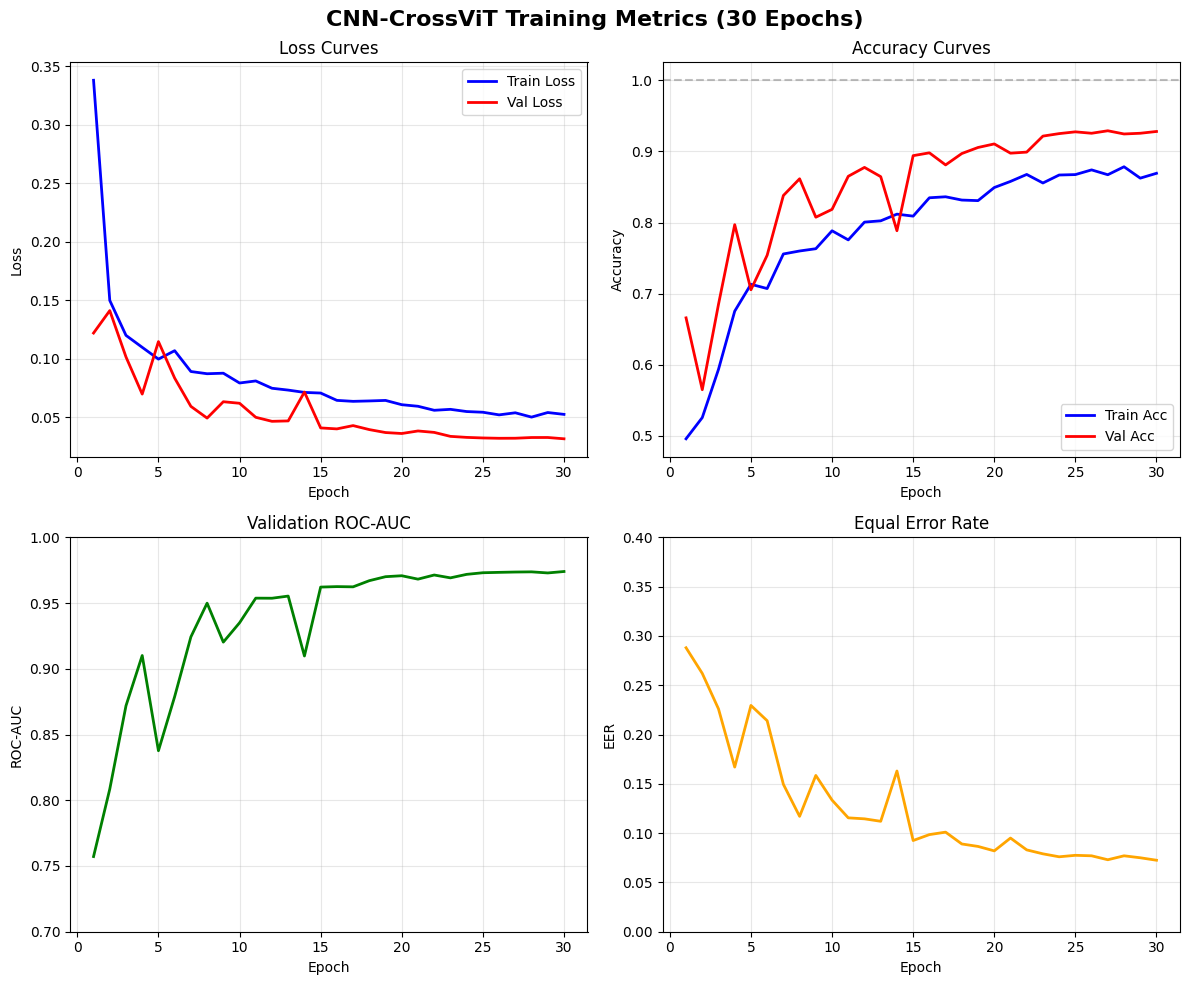

Best ROC-AUC: 0.9740
Best EER: 0.0725
Final Train Loss: 0.0523
Final Val Loss: 0.0314
Final Train Accuracy: 0.8692
Final Val Accuracy: 0.9280


In [ ]:
epochs = range(1, len(history_cnn_crossvit_c_240['train_loss']) + 1)

# Создаем фигуру с 2x2 подграфиками
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('CNN-CrossViT Training Metrics (30 Epochs)', fontsize=16, fontweight='bold')

# 1. Loss (Train vs Val)
ax = axes[0, 0]
ax.plot(epochs, history_cnn_crossvit_c_240['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax.plot(epochs, history_cnn_crossvit_c_240['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 31, 5))

# 2. Accuracy (Train vs Val)
ax = axes[0, 1]
ax.plot(epochs, history_cnn_crossvit_c_240['train_acc'], 'b-', label='Train Acc', linewidth=2)
ax.plot(epochs, history_cnn_crossvit_c_240['val_acc'], 'r-', label='Val Acc', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Curves')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 31, 5))
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

# 3. ROC-AUC
ax = axes[1, 0]
ax.plot(epochs, history_cnn_crossvit_c_240['val_roc_auc'], 'g-', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC')
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 31, 5))
ax.set_ylim([0.7, 1.0])

# 4. EER (Equal Error Rate) - чем ниже, тем лучше
ax = axes[1, 1]
ax.plot(epochs, history_cnn_crossvit_c_240['val_eer'], 'orange', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('EER')
ax.set_title('Equal Error Rate')
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 31, 5))
ax.set_ylim([0, 0.4])

plt.tight_layout()
plt.savefig('CNN-CrossViT_metrics_c_240.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best ROC-AUC: {max(history_cnn_crossvit_c_240['val_roc_auc']):.4f}")
print(f"Best EER: {min(history_cnn_crossvit_c_240['val_eer']):.4f}")
print(f"Final Train Loss: {history_cnn_crossvit_c_240['train_loss'][-1]:.4f}")
print(f"Final Val Loss: {history_cnn_crossvit_c_240['val_loss'][-1]:.4f}")
print(f"Final Train Accuracy: {history_cnn_crossvit_c_240['train_acc'][-1]:.4f}")
print(f"Final Val Accuracy: {history_cnn_crossvit_c_240['val_acc'][-1]:.4f}")

In [21]:
checkpoint = torch.load('best_cnn_crossvit_c_240 (3).pth', map_location='cpu', weights_only=False)

In [22]:
model = CNNCrossViT(    embedding_size=256,
    pretrained=False,
    freeze_backbone=None
)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

CNN-CrossViT initialized. Embedding size: 256
Total parameters: 107,564,224
Trainable parameters: 107,564,224 (100.0%)


CNNCrossViT(
  (cnn_conv1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (cnn_layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [23]:
model=model.to(device)

In [24]:
def calculate_eer(labels, scores):
    """
    Calculate Equal Error Rate (EER)
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer


def evaluate_model(model, test_loader, device, val_threshold=None, checkpoint_path=None):
    """
    Evaluate model on test dataset.
    Uses Euclidean distance (consistent with Contrastive Loss training).

    Args:
        model: trained CNNCrossViT model
        test_loader: DataLoader with test pairs
        device: cuda/cpu
        val_threshold: threshold from validation set (REQUIRED)
        checkpoint_path: optional path to load model checkpoint
    """
    model.eval()

    all_distances = []
    all_labels = []


    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):

            img1, img2, labels = batch


            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            # Forward pass
            emb1, emb2 = model(img1, img2)

            # Euclidean distance
            distances = torch.norm(emb1 - emb2, p=2, dim=1)

            all_distances.extend(distances.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_distances = np.array(all_distances)
    all_labels = np.array(all_labels)

    # 1. ROC-AUC 
    roc_auc = roc_auc_score(all_labels, -all_distances)

    # 2. EER 
    eer = calculate_eer(all_labels, -all_distances)

    # 3.Accuracy with validation threshold
    main_threshold = val_threshold
    main_predictions = (all_distances <= main_threshold).astype(int)
    main_accuracy = accuracy_score(all_labels, main_predictions)

    # 4. Confusion matrix with validation threshold
    cm = confusion_matrix(all_labels, main_predictions)
    tn, fp, fn, tp = cm.ravel()

    # 5. FAR, FRR with validation threshold
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0

    # 6. Distance statistics
    pos_distances = all_distances[all_labels == 1]
    neg_distances = all_distances[all_labels == 0]

    results = {
        'roc_auc': roc_auc,
        'eer': eer,
        'val_threshold': val_threshold,
        'main_accuracy': main_accuracy,
        'far': far,
        'frr': frr,
        'mean_distance_same': pos_distances.mean() if len(pos_distances) > 0 else 0,
        'std_distance_same': pos_distances.std() if len(pos_distances) > 0 else 0,
        'mean_distance_diff': neg_distances.mean() if len(neg_distances) > 0 else 0,
        'std_distance_diff': neg_distances.std() if len(neg_distances) > 0 else 0,
        'distance_gap': neg_distances.mean() - pos_distances.mean() if len(pos_distances) > 0 and len(neg_distances) > 0 else 0,
        'confusion_matrix': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'num_samples': len(all_labels),
        'num_positive': int((all_labels == 1).sum()),
        'num_negative': int((all_labels == 0).sum()),
    }

    print(f"Samples: {results['num_samples']} (pos={results['num_positive']}, neg={results['num_negative']})")
    print(f"Threshold: {main_threshold:.4f} (from Validation)")

    print(f"ROC-AUC:           {results['roc_auc']:.4f}")
    print(f"EER:               {results['eer']:.4f}")
    print(f"Accuracy:          {results['main_accuracy']:.4f}")


    print(f"Same author:       {results['mean_distance_same']:.4f} ± {results['std_distance_same']:.4f}")
    print(f"Diff authors:      {results['mean_distance_diff']:.4f} ± {results['std_distance_diff']:.4f}")
    print(f"Gap:               {results['distance_gap']:.4f}")

    print(f"TN={tn:5d}  FP={fp:5d}")
    print(f"FN={fn:5d}  TP={tp:5d}")


    return results

In [26]:
test_results = evaluate_model(
        model=model,
        test_loader=test_loader,
        device=device,
        val_threshold=0.457
    )

Testing: 100%|██████████| 125/125 [00:38<00:00,  3.25it/s]

Samples: 1000 (pos=536, neg=464)
Threshold: 0.4570 (from Validation)
ROC-AUC:           0.9821
EER:               0.0580
Accuracy:          0.9400
Same author:       0.1743 ± 0.1357
Diff authors:      1.0072 ± 0.3659
Gap:               0.8329
TN=  422  FP=   42
FN=   18  TP=  518


Now let's check the model 

In [27]:
file_id = "1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk"
output_name = "icdar_chinese.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk
From (redirected): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk&confirm=t&uuid=5e3bb2d1-f650-4e33-ba68-5e16fbe16740
To: /content/icdar_chinese.zip
100% 405M/405M [00:04<00:00, 87.1MB/s]


In [28]:
with zipfile.ZipFile("icdar_chinese.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'all_data_3']

In [29]:

file_id = "1-v5SoXymV55kyZMjoJGXMHrIjo9_COPO"
output_name = "icdar_chinese_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-v5SoXymV55kyZMjoJGXMHrIjo9_COPO
To: /content/icdar_chinese_pairs.pkl
100% 123k/123k [00:00<00:00, 85.7MB/s]


In [35]:
DATA_ROOT_icdar_chinese = "icdar_chinese_pairs.pkl"

In [36]:
test_icdar_chinese_dataset = SavedPairsDataset(DATA_ROOT_icdar_chinese, transform=test_transform)

In [37]:
test_icdar_chinese_loader = DataLoader(
    dataset=test_icdar_chinese_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [38]:

file_id = "1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK"
output_name = "icdar_dutch.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK
From (redirected): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK&confirm=t&uuid=22350aef-a648-4c9b-b277-46f04c851714
To: /content/icdar_dutch.zip
100% 388M/388M [00:02<00:00, 145MB/s]


In [39]:
with zipfile.ZipFile("icdar_dutch.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'all_data_3', 'icdar_dutch']

In [40]:
file_id = "1glxrUV2kPnFy8QV83GaouOVLLkl37SnM"
output_name = "icdar_dutch_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1glxrUV2kPnFy8QV83GaouOVLLkl37SnM
To: /content/icdar_dutch_pairs.pkl
100% 178k/178k [00:00<00:00, 85.5MB/s]


In [41]:
DATA_ROOT_icdar_dutch = "icdar_dutch_pairs.pkl"

In [42]:
test_icdar_dutch_dataset = SavedPairsDataset(DATA_ROOT_icdar_dutch, transform=test_transform)

In [43]:
test_icdar_dutch_loader = DataLoader(
    dataset=test_icdar_dutch_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [44]:
file_id = "17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ"
output_name = "cvl.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ
From (redirected): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ&confirm=t&uuid=2eb85bb5-a6d2-4601-b4d0-90013380c3d6
To: /content/cvl.zip
100% 277M/277M [00:02<00:00, 96.6MB/s]


In [45]:
with zipfile.ZipFile("cvl.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'cvl', 'all_data_3', 'icdar_dutch']

In [46]:
file_id = "1mjoQxiMCbANwCcNtE4auF9XWgWrvhhAu"
output_name = "cvl_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1mjoQxiMCbANwCcNtE4auF9XWgWrvhhAu
To: /content/cvl_pairs.pkl
100% 171k/171k [00:00<00:00, 102MB/s]


In [47]:
DATA_ROOT_cvl = "cvl_pairs.pkl"

In [48]:
test_cvl_dataset = SavedPairsDataset('cvl_pairs.pkl', transform=test_transform)

In [49]:
test_cvl_loader = DataLoader(
    dataset=test_cvl_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [50]:
result_icdar_chinese = evaluate_model(
        model=model,
        test_loader=test_icdar_chinese_loader,
        device=device,
        val_threshold=0.457  
    )



Testing: 100%|██████████| 625/625 [05:21<00:00,  1.95it/s]

Samples: 5000 (pos=2473, neg=2527)
Threshold: 0.4570 (from Validation)
ROC-AUC:           0.7220
EER:               0.3288
Accuracy:          0.6028
Same author:       0.2354 ± 0.2067
Diff authors:      0.3817 ± 0.2455
Gap:               0.1462
TN=  744  FP= 1783
FN=  203  TP= 2270


In [51]:
result_icdar_dutch = evaluate_model(
        model=model,
        test_loader=test_icdar_dutch_loader,
        device=device,
        val_threshold=0.457  
    )


Testing: 100%|██████████| 625/625 [03:25<00:00,  3.03it/s]

Samples: 5000 (pos=2418, neg=2582)
Threshold: 0.4570 (from Validation)
ROC-AUC:           0.8702
EER:               0.2022
Accuracy:          0.7022
Same author:       0.1502 ± 0.1316
Diff authors:      0.5250 ± 0.3796
Gap:               0.3748
TN= 1171  FP= 1411
FN=   78  TP= 2340


In [52]:
result_cvl = evaluate_model(
        model=model,
        test_loader=test_cvl_loader,
        device=device,
        val_threshold=0.457  
    )


Testing: 100%|██████████| 625/625 [03:28<00:00,  3.00it/s]

Samples: 5000 (pos=2546, neg=2454)
Threshold: 0.4570 (from Validation)
ROC-AUC:           0.8323
EER:               0.2382
Accuracy:          0.5754
Same author:       0.1284 ± 0.1112
Diff authors:      0.2895 ± 0.1683
Gap:               0.1611
TN=  363  FP= 2091
FN=   32  TP= 2514


In [53]:
img=test_dataset[0][0]

Let's look at feature maps of trained model

In [54]:
def visualize_all_feature_maps(model, image, device, layer_names=None, num_channels=8):
    """
    Visualize feature maps from ANY layers (frozen or trainable).
    Also displays the original input image for reference.
    """
    model.eval()
    original_image = image.cpu().clone()  # Save original for display
    image = image.to(device)

    features = {}

    def get_hook(name):
        def hook(module, input, output):
            features[name] = output.detach()
        return hook

    # List of layers to visualize (any layers can be added)
    if layer_names is None:
        layer_names = [
            'cnn_conv1',          
            'cnn_layer1',         
            'cnn_layer2',         
            'cnn_layer3',        
            'fpn_lateral.0',       
            'fpn_output.0',        
            'crossvit.patch_embed.0.proj', 
            'crossvit.blocks.0.fusion.0.attn.proj',  
        ]

    hooks = []
    for name in layer_names:
        # Parse layer name (supports nested attributes and indices)
        parts = name.split('.')
        layer = model
        for part in parts:
            if part.isdigit():
                layer = layer[int(part)]
            elif hasattr(layer, part):
                layer = getattr(layer, part)
            else:
                print(f"Warning: Layer '{name}' not found")
                break
        else:
            hook = layer.register_forward_hook(get_hook(name))
            hooks.append(hook)

    with torch.no_grad():
        _ = model.forward_one(image)

    # Filter to only include layers that were successfully found
    valid_layers = [name for name in layer_names if name in features]
    n_layers = len(valid_layers)

    # Create figure: +1 row for the original image
    fig, axes = plt.subplots(n_layers + 1, num_channels, figsize=(num_channels * 2, (n_layers + 1) * 2))

    # Display original image in the first row
    orig_display = original_image.squeeze().cpu().numpy()
    # Normalize for display
    orig_display = (orig_display - orig_display.min()) / (orig_display.max() - orig_display.min())

    for j in range(num_channels):
        ax = axes[0, j]
        if j == 0:
            ax.imshow(orig_display, cmap='gray')
            ax.set_ylabel('Original\nImage', fontsize=8)
        else:
            ax.axis('off')
        ax.set_title(f'ch{j}' if j == 0 else '', fontsize=6)
        ax.axis('off')

    row = 1
    for name in valid_layers:
        feat = features[name][0]  # [C, H, W]
        num_feat_channels = min(num_channels, feat.shape[0])

        for j in range(num_feat_channels):
            ax = axes[row, j]
            channel = feat[j].cpu()

            # Normalize for visualization
            if channel.std() > 0:
                vmin = channel.quantile(0.05).item()
                vmax = channel.quantile(0.95).item()
                im = ax.imshow(channel, cmap='viridis', vmin=vmin, vmax=vmax)
            else:
                im = ax.imshow(channel, cmap='viridis')

            ax.axis('off')
            if j == 0:
                ax.set_ylabel(name, fontsize=8)

        # Fill empty subplots
        for j in range(num_feat_channels, num_channels):
            axes[row, j].axis('off')

        row += 1

    plt.suptitle('Feature Maps (Original Image + Layer Activations)', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Remove hooks
    for hook in hooks:
        hook.remove()

    return features

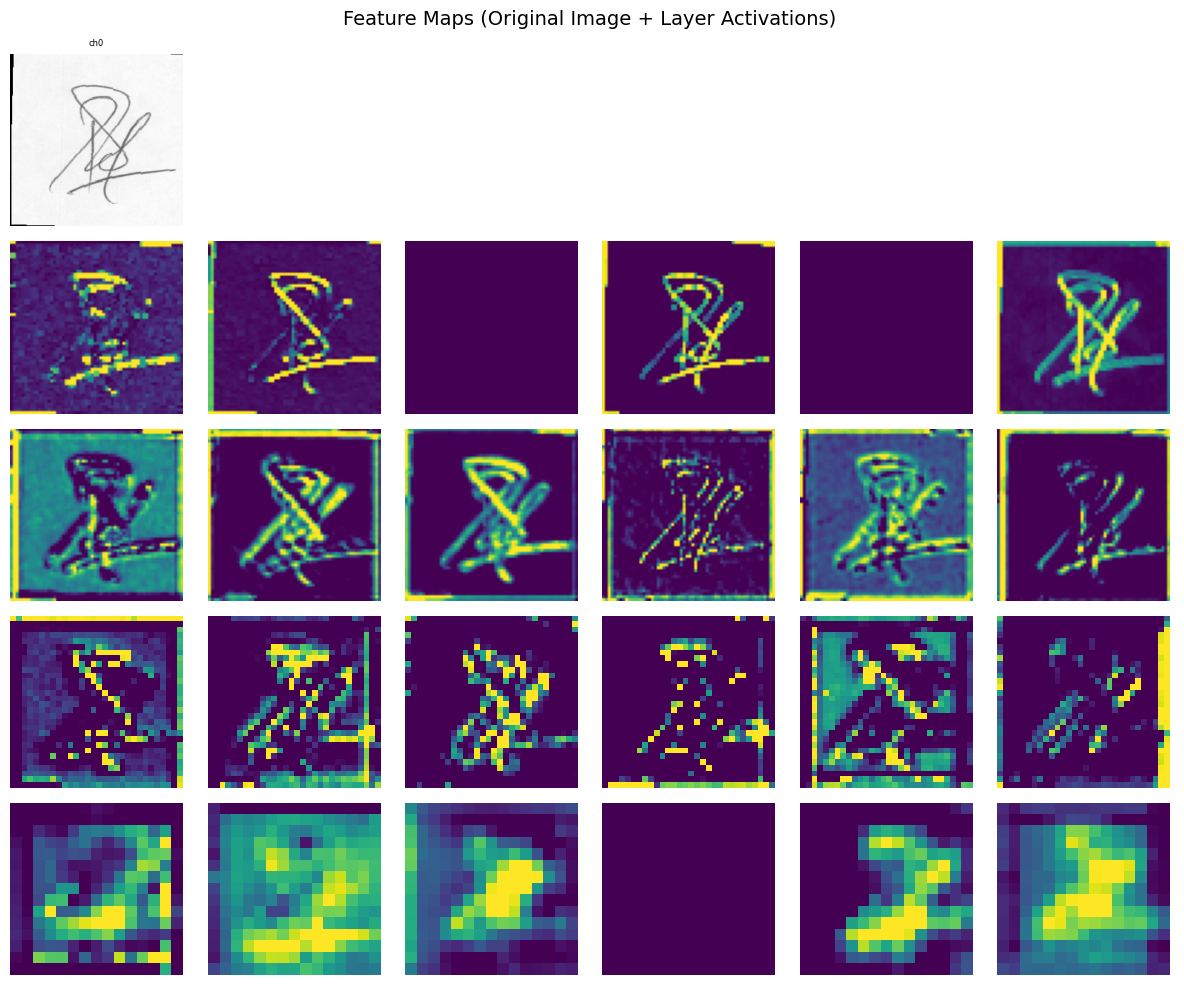

In [57]:
img = train_dataset[2][0]
img = img.unsqueeze(0).to(device)
features = visualize_all_feature_maps(
        model,
        img,
        device,
        layer_names= [
            'cnn_conv1',
            'cnn_layer1',
            'cnn_layer2',
            'cnn_layer3',
        ],
        num_channels=6
    )


In [58]:
def visualize_saliency_maps(model, image, device, branch='both'):
    """
    Visualize which pixels are most important using gradients.

    Args:
        branch: 'cnn', 'crossvit', or 'both'
    """
    model.eval()
    image = image.to(device)
    image.requires_grad_(True)  

    def get_saliency(branch_name):
        # Clear previous gradients
        if image.grad is not None:
            image.grad.zero_()

        # Forward pass
        if branch_name == 'cnn':
            c1 = model.cnn_conv1(image)
            c2 = model.cnn_layer1(c1)
            c3 = model.cnn_layer2(c2)
            c4 = model.cnn_layer3(c3)
            c5 = model.cnn_layer4(c4)
            cnn_features = model._fpn_forward(c2, c3, c4, c5)
            output = cnn_features.sum()
        elif branch_name == 'crossvit':
            crossvit_features = model.crossvit(image)
            output = crossvit_features.sum()
        else:  # both
            emb = model.forward_one(image)
            output = emb.sum()

        # Backward pass
        output.backward()

        # Get saliency map
        saliency = image.grad.abs().detach().cpu().numpy()
        saliency = saliency[0, 0]  # [1, 1, H, W] → [H, W]

        return saliency

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image (detach for safety)
    axes[0].imshow(image[0, 0].detach().cpu(), cmap='gray')
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    # Saliency map
    saliency = get_saliency(branch)
    im = axes[1].imshow(saliency, cmap='hot')
    axes[1].set_title(f'Saliency Map ({branch})')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1])

    # Overlay (blended image and saliency map)
    axes[2].imshow(image[0, 0].detach().cpu(), cmap='gray', alpha=0.5)
    axes[2].imshow(saliency, cmap='hot', alpha=0.5)
    axes[2].set_title('Overlay (Saliency + Image)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Clear gradients after use to avoid memory issues
    if image.grad is not None:
        image.grad = None


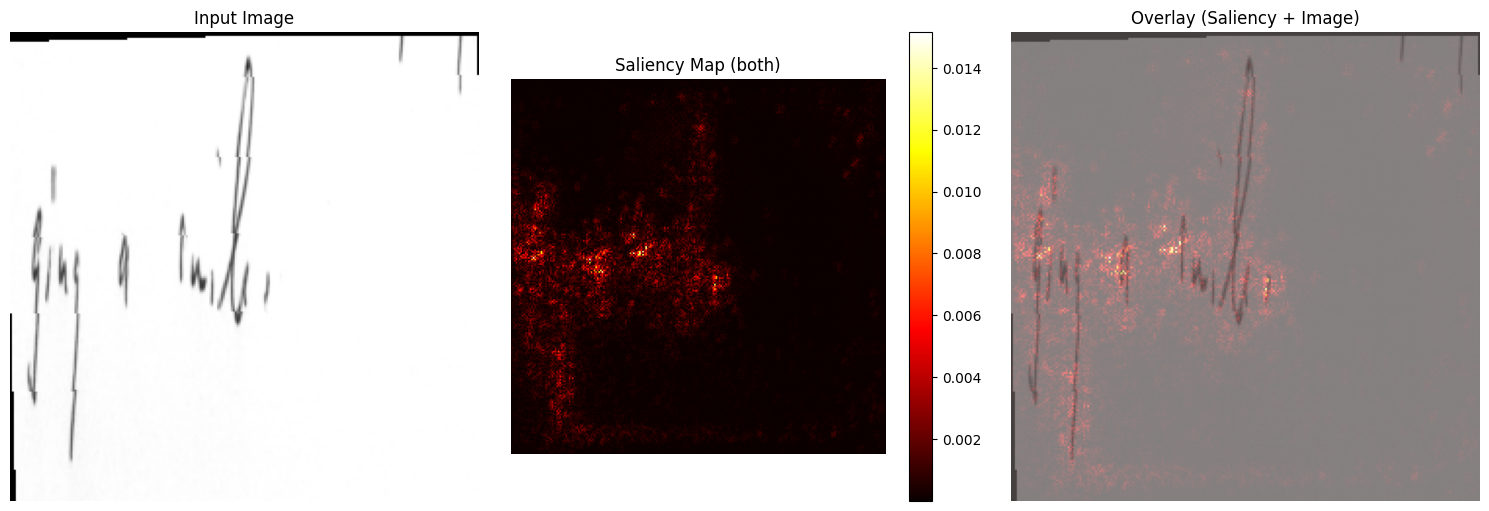

In [63]:
visualize_saliency_maps(model, train_dataset[0][0].unsqueeze(0).to(device), device)

Now let's visualize embeddings

In [64]:
def visualize_author_embeddings(model, cedar_root, author_ids, transform, device):
    """
    Visualize embeddings for selected authors from CEDAR dataset.
    """
    model.eval()

    embeddings = []
    labels = []
    colors_list = []
    marker_styles = []

    # Colors for different authors
    author_colors = ['blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta']
    # Marker styles: o for original, x for forgery
    marker_map = {'original': 'o', 'forgery': 'x'}

    for author_idx, author_id in enumerate(author_ids):
        author_color = author_colors[author_idx % len(author_colors)]

        # Load original signatures
        original_path = os.path.join(cedar_root, 'original', author_id)
        if os.path.exists(original_path):
            for img_file in os.listdir(original_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(original_path, img_file)
                    img = Image.open(img_path).convert('L')
                    img_tensor = transform(img).unsqueeze(0).to(device)

                    with torch.no_grad():
                        emb = model.forward_one(img_tensor).cpu().numpy()[0]

                    embeddings.append(emb)
                    labels.append(f'Author {author_id}')
                    colors_list.append(author_color)
                    marker_styles.append('o')

        # Load forgery signatures
        forgery_path = os.path.join(cedar_root, 'forgery', author_id)
        if os.path.exists(forgery_path):
            for img_file in os.listdir(forgery_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(forgery_path, img_file)
                    img = Image.open(img_path).convert('L')
                    img_tensor = transform(img).unsqueeze(0).to(device)

                    with torch.no_grad():
                        emb = model.forward_one(img_tensor).cpu().numpy()[0]

                    embeddings.append(emb)
                    labels.append(f'Author {author_id}')
                    colors_list.append(author_color)
                    marker_styles.append('x')

    embeddings = np.array(embeddings)

    # t-SNE
    perplexity = min(30, len(embeddings) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(12, 10))

    # Plot each point individually with correct color and marker
    for i, (x, y) in enumerate(embeddings_2d):
        plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],
                   s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

    # Create custom legend
    legend_elements = []
    for author_idx, author_id in enumerate(author_ids):
        author_color = author_colors[author_idx % len(author_colors)]
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=author_color,
                                          markersize=10, label=f'Author {author_id} (original)'))
        legend_elements.append(plt.Line2D([0], [0], marker='x', color='w',
                                          markerfacecolor=author_color,
                                          markersize=10, label=f'Author {author_id} (forgery)'))

    plt.legend(handles=legend_elements, fontsize=9, loc='best')
    plt.title(f't-SNE visualization of embeddings for {len(author_ids)} authors\n(o = original, x = forgery)', fontsize=14)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    for author_id in author_ids:
        # Get indices for this author
        author_indices = [i for i, label in enumerate(labels) if label == f'Author {author_id}']
        orig_indices = [i for i in author_indices if marker_styles[i] == 'o']
        forg_indices = [i for i in author_indices if marker_styles[i] == 'x']

        print(f"\nAuthor {author_id}:")
        print(f"  Original signatures: {len(orig_indices)}")
        print(f"  Forgery signatures: {len(forg_indices)}")

        if len(orig_indices) > 0 and len(forg_indices) > 0:
            orig_center = np.mean(embeddings[orig_indices], axis=0)
            forg_center = np.mean(embeddings[forg_indices], axis=0)
            dist = np.linalg.norm(orig_center - forg_center)
            print(f"  Distance between original and forgery centers: {dist:.4f}")

/tmp/ipykernel_1207/800764944.py:77: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],


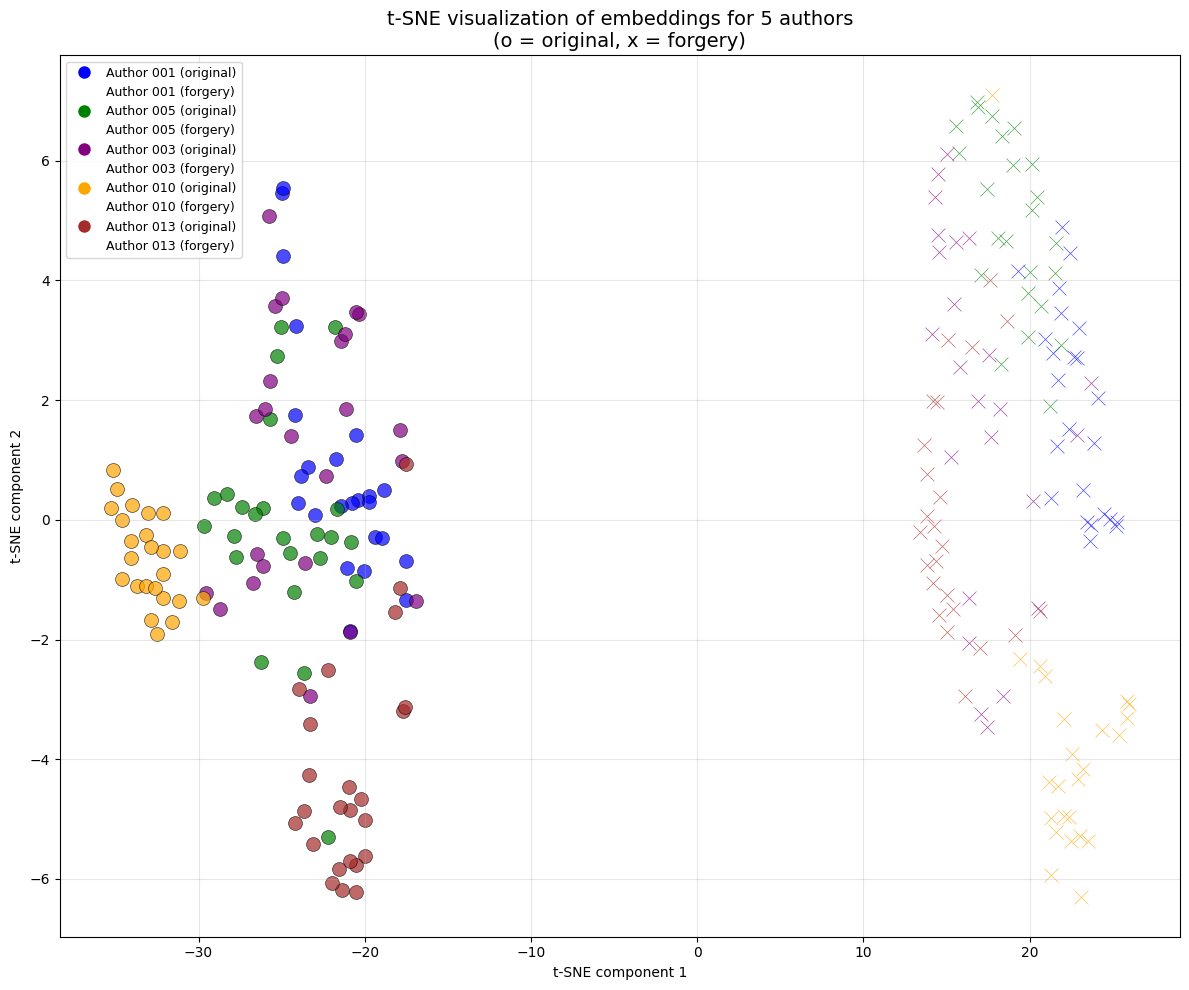


Author 001:
  Original signatures: 24
  Forgery signatures: 24
  Distance between original and forgery centers: 1.3930

Author 005:
  Original signatures: 24
  Forgery signatures: 24
  Distance between original and forgery centers: 1.2791

Author 003:
  Original signatures: 24
  Forgery signatures: 24
  Distance between original and forgery centers: 1.2553

Author 010:
  Original signatures: 24
  Forgery signatures: 24
  Distance between original and forgery centers: 1.3362

Author 013:
  Original signatures: 24
  Forgery signatures: 24
  Distance between original and forgery centers: 1.2548


In [65]:
author_ids = ['001', '005', '003', '010', '013']  

cedar_root = '/kaggle/working/all_data_3/cedar' 

visualize_author_embeddings(model, cedar_root, author_ids, test_transform, device)

In [66]:
def visualize_iam_embeddings(model, iam_root, author_ids, transform, device):
    """
    Visualize embeddings for selected authors from IAM dataset.

    Args:
        model: trained model
        iam_root: path to IAM folder (contains subfolders with author IDs)
        author_ids: list of author IDs to visualize (e.g., ['001', '002', '003'])
        transform: image transformations
        device: cuda or cpu
    """
    model.eval()

    embeddings = []
    labels = []
    colors_list = []

    # Colors for different authors
    author_colors = ['blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta']

    valid_author_ids = []

    for author_idx, author_id in enumerate(author_ids):
        author_color = author_colors[author_idx % len(author_colors)]
        author_path = os.path.join(iam_root, author_id)


        valid_author_ids.append(author_id)

        # Load all images for this author
        image_files = [f for f in os.listdir(author_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.bmp'))]


        for img_file in image_files:
            img_path = os.path.join(author_path, img_file)
            try:
                img = Image.open(img_path).convert('L')
                img_tensor = transform(img).unsqueeze(0).to(device)

                with torch.no_grad():
                    emb = model.forward_one(img_tensor).cpu().numpy()[0]

                embeddings.append(emb)
                labels.append(f'Author {author_id}')
                colors_list.append(author_color)
            except Exception as e:
              print(f"Error loading image {img_path}: {e}")
              continue

    embeddings = np.array(embeddings)
    n_samples = len(embeddings)

    # t-SNE with proper perplexity
    if n_samples <= 1:
        print("Need at least 2 samples for t-SNE")
        return
    elif n_samples < 5:
        perplexity = max(1, n_samples - 1)
    else:
        perplexity = min(30, n_samples - 1)


    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(12, 10))

    # Plot each point with different colors per author
    for i, (x, y) in enumerate(embeddings_2d):
        plt.scatter(x, y, c=colors_list[i], marker='o',
                   s=80, alpha=0.7, edgecolors='black', linewidth=0.5)

    # Create custom legend
    legend_elements = []
    for author_idx, author_id in enumerate(valid_author_ids):
        author_color = author_colors[author_idx % len(author_colors)]
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=author_color,
                                          markersize=10, label=f'Author {author_id}'))

    plt.legend(handles=legend_elements, fontsize=10, loc='best')
    plt.title(f't-SNE visualization of IAM embeddings for {len(valid_author_ids)} authors\n({n_samples} total signatures)', fontsize=14)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    for author_id in valid_author_ids:
        author_indices = [i for i, label in enumerate(labels) if label == f'Author {author_id}']
        if len(author_indices) > 1:
            embeddings_author = embeddings[author_indices]
            center = np.mean(embeddings_author, axis=0)

            # Calculate intra-class distances
            intra_distances = []
            for i in range(len(embeddings_author)):
                for j in range(i+1, len(embeddings_author)):
                    dist = np.linalg.norm(embeddings_author[i] - embeddings_author[j])
                    intra_distances.append(dist)

            print(f"\nAuthor {author_id}:")
            print(f"  Number of images: {len(author_indices)}")
            print(f"  Mean intra-class distance: {np.mean(intra_distances):.4f}")
            print(f"  Std intra-class distance: {np.std(intra_distances):.4f}")
            print(f"  Min distance: {np.min(intra_distances):.4f}")
            print(f"  Max distance: {np.max(intra_distances):.4f}")
        elif len(author_indices) == 1:
            print(f"\nAuthor {author_id}:")
            print(f"  Number of images: 1")
            print(f"  Cannot compute intra-class distance (need at least 2 images)")

    unique_authors = [f'Author {aid}' for aid in valid_author_ids]
    for i, auth1 in enumerate(unique_authors):
        for j, auth2 in enumerate(unique_authors):
            if i < j:
                idx1 = [k for k, label in enumerate(labels) if label == auth1]
                idx2 = [k for k, label in enumerate(labels) if label == auth2]

                if idx1 and idx2 and len(idx1) > 0 and len(idx2) > 0:
                    center1 = np.mean(embeddings[idx1], axis=0)
                    center2 = np.mean(embeddings[idx2], axis=0)
                    dist = np.linalg.norm(center1 - center2)
                    print(f"  {auth1} vs {auth2}: {dist:.4f}")


    if len(valid_author_ids) >= 2:
        # Calculate average inter-class distance
        inter_distances = []
        for i, auth1 in enumerate(unique_authors):
            for j, auth2 in enumerate(unique_authors):
                if i < j:
                    idx1 = [k for k, label in enumerate(labels) if label == auth1]
                    idx2 = [k for k, label in enumerate(labels) if label == auth2]
                    if idx1 and idx2:
                        center1 = np.mean(embeddings[idx1], axis=0)
                        center2 = np.mean(embeddings[idx2], axis=0)
                        inter_distances.append(np.linalg.norm(center1 - center2))

        # Calculate average intra-class distance
        intra_distances_all = []
        for author_id in valid_author_ids:
            author_indices = [i for i, label in enumerate(labels) if label == f'Author {author_id}']
            if len(author_indices) > 1:
                embeddings_author = embeddings[author_indices]
                for i in range(len(embeddings_author)):
                    for j in range(i+1, len(embeddings_author)):
                        intra_distances_all.append(np.linalg.norm(embeddings_author[i] - embeddings_author[j]))

        if intra_distances_all and inter_distances:
            avg_intra = np.mean(intra_distances_all)
            avg_inter = np.mean(inter_distances)
            separation_ratio = avg_inter / avg_intra if avg_intra > 0 else float('inf')

            print(f"Average intra-class distance: {avg_intra:.4f}")
            print(f"Average inter-class distance: {avg_inter:.4f}")
            print(f"Separation ratio (inter/intra): {separation_ratio:.4f}")
            if separation_ratio > 1:
                print("Authors are well separated (inter > intra)")
            else:
                print("Authors are not well separated (inter < intra)")

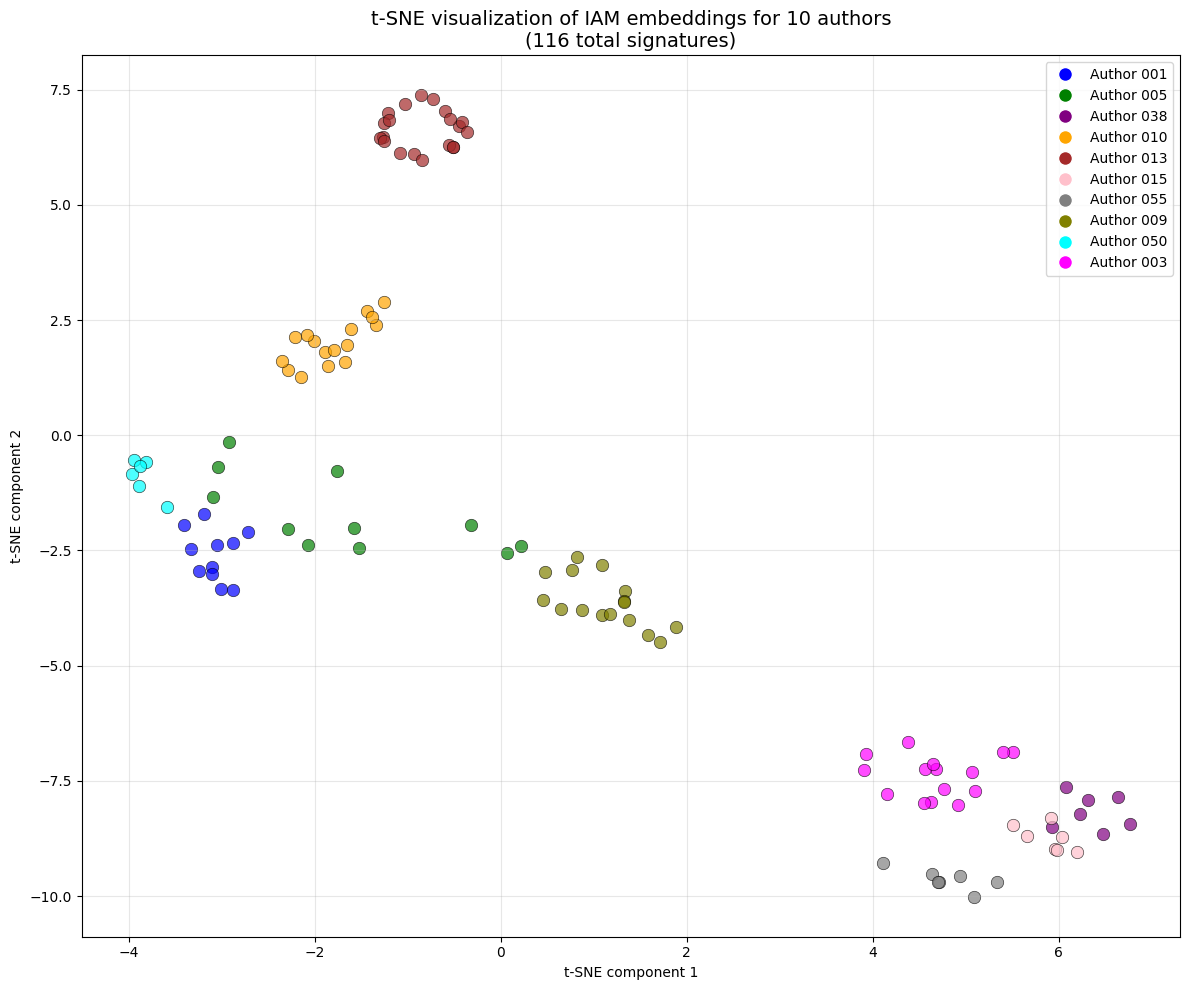


Author 001:
  Number of images: 11
  Mean intra-class distance: 0.2515
  Std intra-class distance: 0.1128
  Min distance: 0.0659
  Max distance: 0.5176

Author 005:
  Number of images: 11
  Mean intra-class distance: 0.3746
  Std intra-class distance: 0.1620
  Min distance: 0.1089
  Max distance: 0.6912

Author 038:
  Number of images: 7
  Mean intra-class distance: 0.1208
  Std intra-class distance: 0.0408
  Min distance: 0.0633
  Max distance: 0.2041

Author 010:
  Number of images: 16
  Mean intra-class distance: 0.2248
  Std intra-class distance: 0.1265
  Min distance: 0.0286
  Max distance: 0.5774

Author 013:
  Number of images: 20
  Mean intra-class distance: 0.1311
  Std intra-class distance: 0.0843
  Min distance: 0.0066
  Max distance: 0.4112

Author 015:
  Number of images: 7
  Mean intra-class distance: 0.0676
  Std intra-class distance: 0.0304
  Min distance: 0.0062
  Max distance: 0.1334

Author 055:
  Number of images: 7
  Mean intra-class distance: 0.1613
  Std intra-c

In [67]:
author_ids = ['001', '005', '038', '010', '013',  '015',  '055',  '009', '050', '003']

iam_root = '/kaggle/working/all_data_3/iam' 

visualize_iam_embeddings(model, iam_root, author_ids, test_transform, device)

In [68]:
def visualize_author_embeddings_hindi(model, hindi_root, author_ids, transform, device):
    """
    Visualize embeddings for selected authors from Hindi dataset.
    Dataset structure: hindi_root/author_id/genuine/ and hindi_root/author_id/forge/
    """
    model.eval()

    embeddings = []
    labels = []
    colors_list = []
    marker_styles = []

    # Colors for different authors
    author_colors = ['blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta']
    # Marker styles: o for genuine, x for forge
    marker_map = {'genuine': 'o', 'forge': 'x'}

    for author_idx, author_id in enumerate(author_ids):
        author_color = author_colors[author_idx % len(author_colors)]
        author_path = os.path.join(hindi_root, author_id)

        if not os.path.exists(author_path):
            print(f"Warning: Author path {author_path} does not exist")
            continue

        # Load genuine signatures
        genuine_path = os.path.join(author_path, 'genuine')
        if os.path.exists(genuine_path):
            for img_file in os.listdir(genuine_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', 'tif')):
                    img_path = os.path.join(genuine_path, img_file)
                    img = Image.open(img_path).convert('L')
                    img_tensor = transform(img).unsqueeze(0).to(device)

                    with torch.no_grad():
                        emb = model.forward_one(img_tensor).cpu().numpy()[0]

                    embeddings.append(emb)
                    labels.append(f'Author {author_id}')
                    colors_list.append(author_color)
                    marker_styles.append('o')

        # Load forge signatures
        forge_path = os.path.join(author_path, 'forge')
        if os.path.exists(forge_path):
            for img_file in os.listdir(forge_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', 'tif')):
                    img_path = os.path.join(forge_path, img_file)
                    img = Image.open(img_path).convert('L')
                    img_tensor = transform(img).unsqueeze(0).to(device)

                    with torch.no_grad():
                        emb = model.forward_one(img_tensor).cpu().numpy()[0]

                    embeddings.append(emb)
                    labels.append(f'Author {author_id}')
                    colors_list.append(author_color)
                    marker_styles.append('x')

    if len(embeddings) < 2:
        print("Not enough embeddings found. Check the paths.")
        return

    embeddings = np.array(embeddings)

    # t-SNE
    perplexity = min(30, len(embeddings) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(12, 10))

    # Plot each point individually with correct color and marker
    for i, (x, y) in enumerate(embeddings_2d):
        plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],
                   s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

    # Create custom legend
    legend_elements = []
    for author_idx, author_id in enumerate(author_ids):
        author_color = author_colors[author_idx % len(author_colors)]
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=author_color,
                                          markersize=10, label=f'Author {author_id} (genuine)'))
        legend_elements.append(plt.Line2D([0], [0], marker='x', color='w',
                                          markerfacecolor=author_color,
                                          markersize=10, label=f'Author {author_id} (forge)'))

    plt.legend(handles=legend_elements, fontsize=9, loc='best')
    plt.title(f't-SNE visualization of embeddings for {len(author_ids)} authors\n(o = genuine, x = forge)', fontsize=14)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print statistics for each author
    for author_id in author_ids:
        # Get indices for this author
        author_indices = [i for i, label in enumerate(labels) if label == f'Author {author_id}']
        genuine_indices = [i for i in author_indices if marker_styles[i] == 'o']
        forge_indices = [i for i in author_indices if marker_styles[i] == 'x']

        print(f"\nAuthor {author_id}:")
        print(f"  Genuine signatures: {len(genuine_indices)}")
        print(f"  Forge signatures: {len(forge_indices)}")

        if len(genuine_indices) > 0 and len(forge_indices) > 0:
            genuine_center = np.mean(embeddings[genuine_indices], axis=0)
            forge_center = np.mean(embeddings[forge_indices], axis=0)
            dist = np.linalg.norm(genuine_center - forge_center)
            print(f"  Distance between genuine and forge centers: {dist:.4f}")

/tmp/ipykernel_1207/3220041324.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],


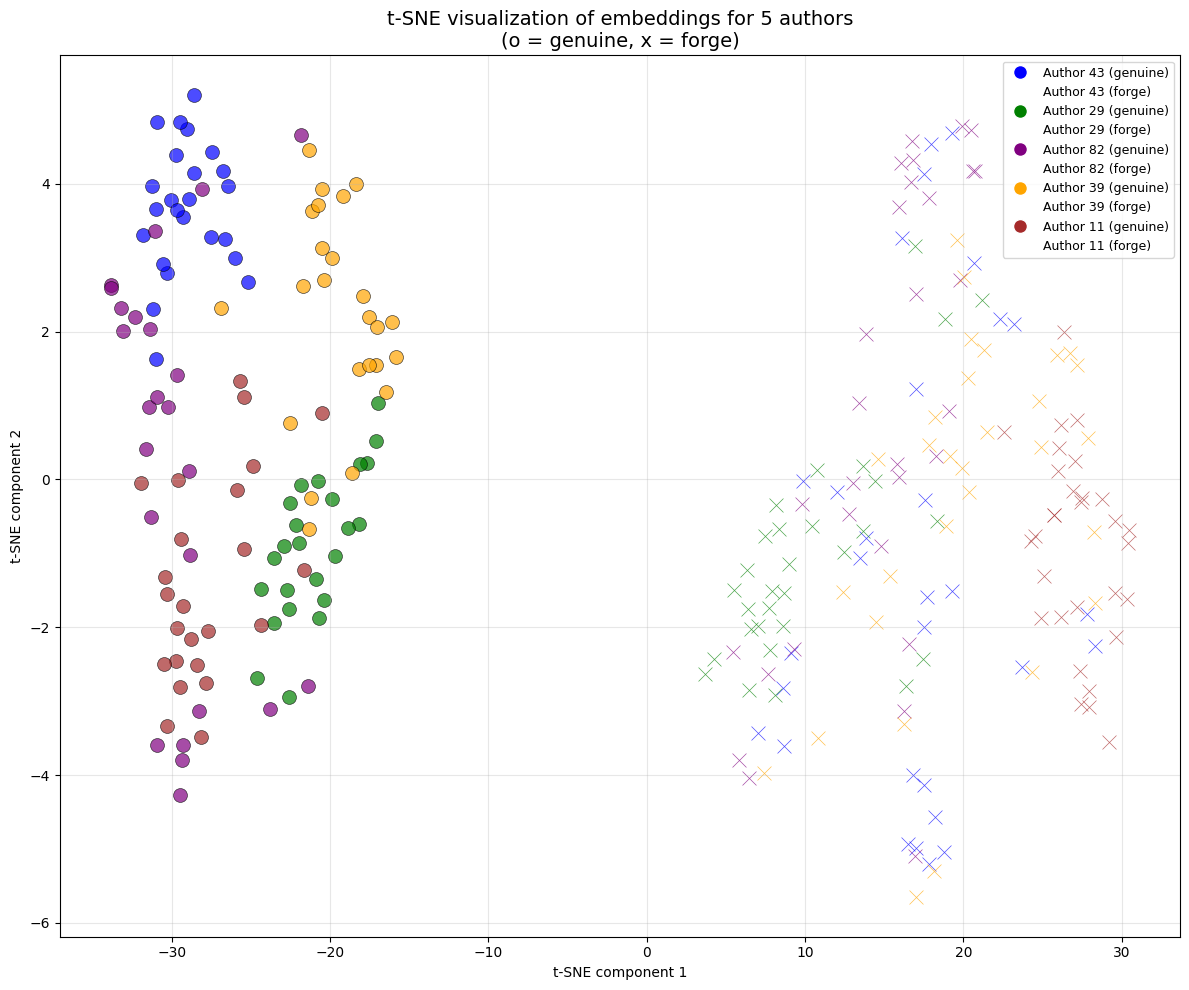


Author 43:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.2212

Author 29:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 0.9408

Author 82:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.2469

Author 39:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.0786

Author 11:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.4253


In [69]:
author_ids = ['43', '29', '82', '39', '11']

hindi_root = '/kaggle/working/all_data_3/hindi'

visualize_author_embeddings_hindi(model, hindi_root, author_ids, test_transform, device)

/tmp/ipykernel_1207/3220041324.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],


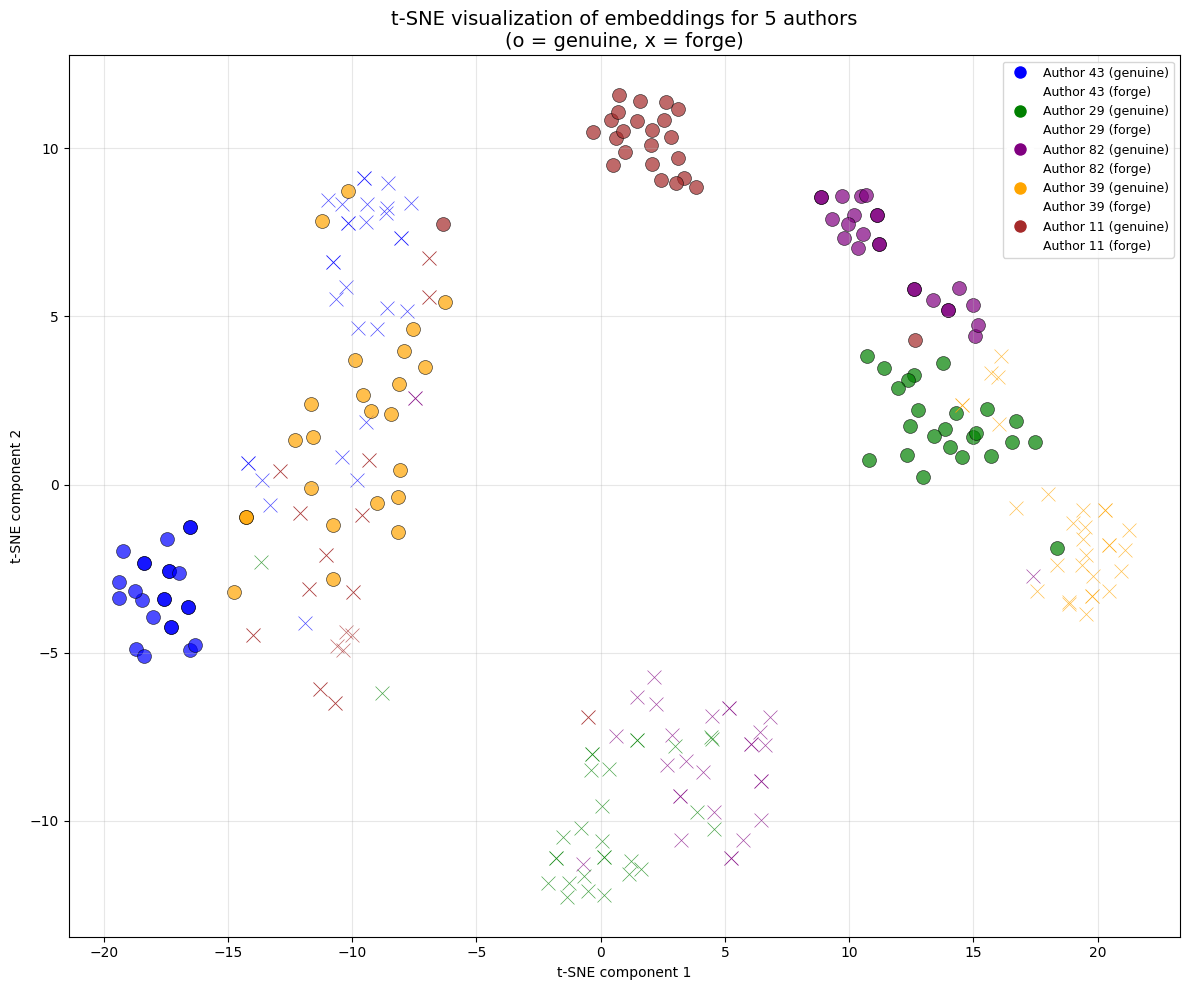


Author 43:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 0.4915

Author 29:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 0.9462

Author 82:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 0.9434

Author 39:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.3728

Author 11:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 0.8946


In [70]:
author_ids = ['43', '29', '82', '39', '11']

bengali_root = '/kaggle/working/all_data_3/bengali'

visualize_author_embeddings_hindi(model, bengali_root, author_ids, test_transform, device)

/tmp/ipykernel_1207/3220041324.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],


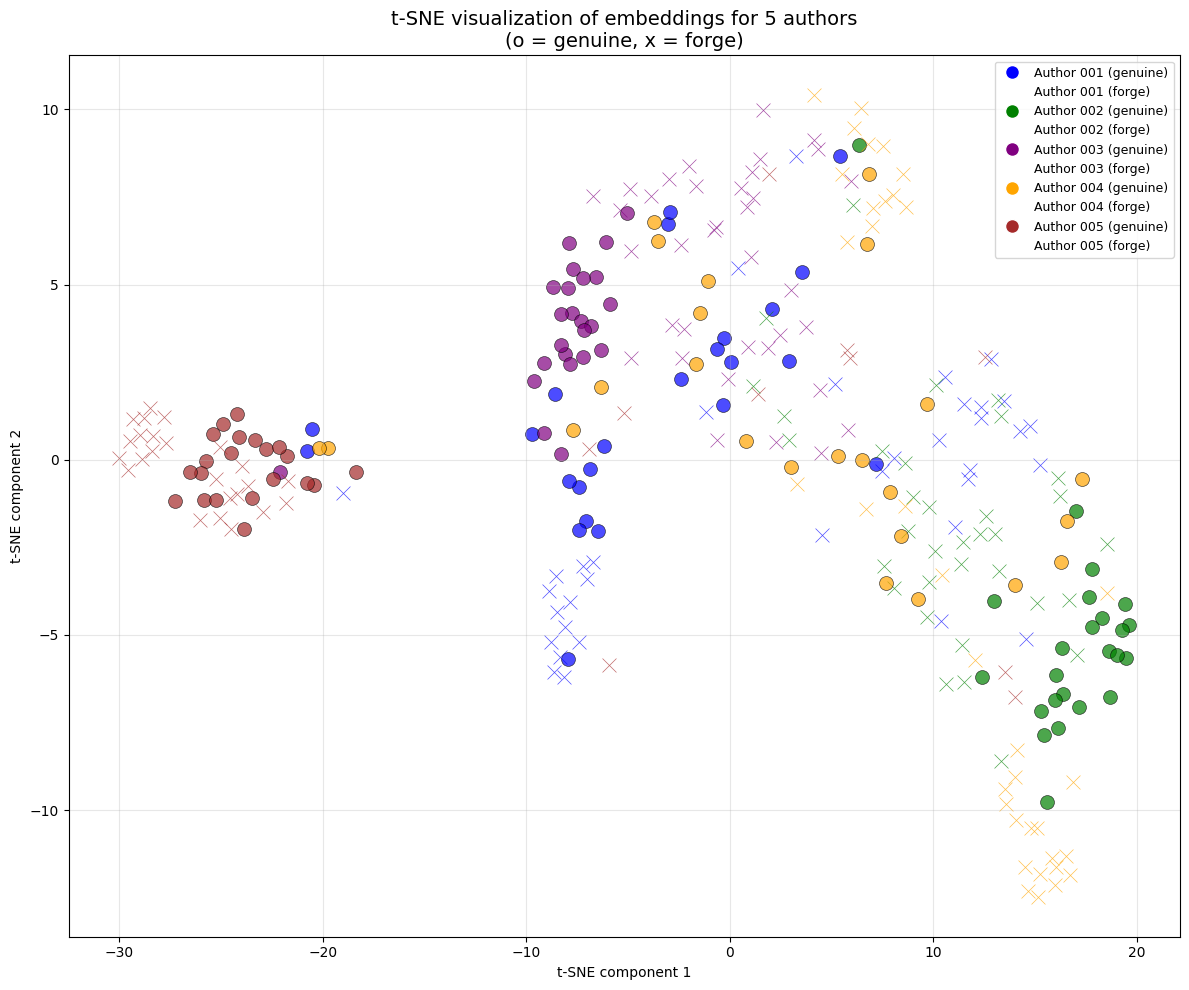


Author 001:
  Genuine signatures: 24
  Forge signatures: 36
  Distance between genuine and forge centers: 0.2233

Author 002:
  Genuine signatures: 24
  Forge signatures: 34
  Distance between genuine and forge centers: 0.3387

Author 003:
  Genuine signatures: 24
  Forge signatures: 36
  Distance between genuine and forge centers: 0.2532

Author 004:
  Genuine signatures: 24
  Forge signatures: 36
  Distance between genuine and forge centers: 0.4060

Author 005:
  Genuine signatures: 21
  Forge signatures: 34
  Distance between genuine and forge centers: 0.1488


In [71]:
author_ids = ['001', '002', '003', '004', '005']

visualize_author_embeddings_hindi(model, "/kaggle/working/icdar_chinese", author_ids, test_transform, device)

/tmp/ipykernel_1207/3220041324.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],


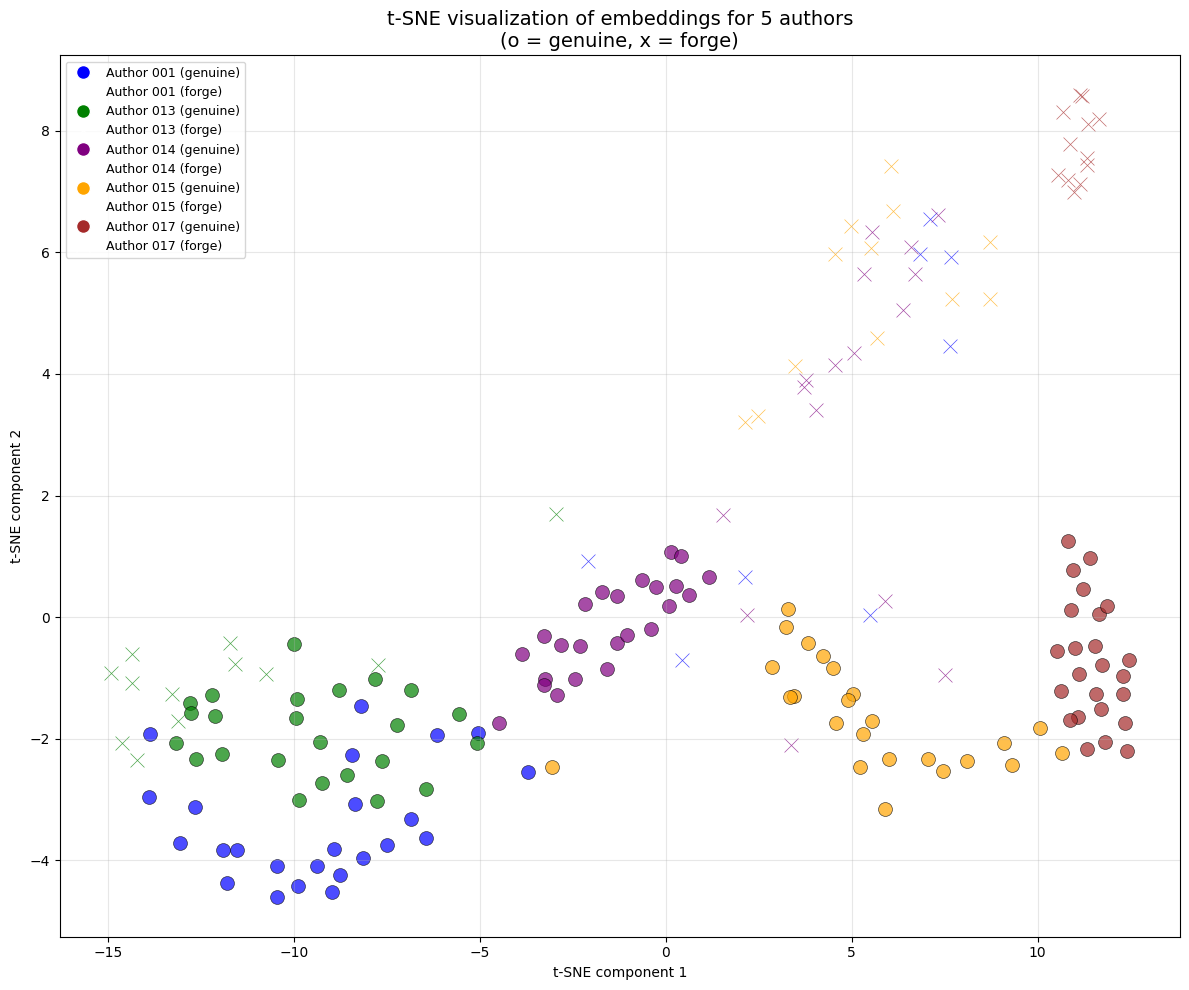


Author 001:
  Genuine signatures: 24
  Forge signatures: 8
  Distance between genuine and forge centers: 0.5319

Author 013:
  Genuine signatures: 24
  Forge signatures: 12
  Distance between genuine and forge centers: 0.1404

Author 014:
  Genuine signatures: 24
  Forge signatures: 16
  Distance between genuine and forge centers: 0.3442

Author 015:
  Genuine signatures: 24
  Forge signatures: 12
  Distance between genuine and forge centers: 0.5072

Author 017:
  Genuine signatures: 24
  Forge signatures: 12
  Distance between genuine and forge centers: 1.0073


In [72]:
author_ids = ['001', '013', '014', '015', '017']

visualize_author_embeddings_hindi(model, "/kaggle/working/icdar_dutch", author_ids, test_transform, device)

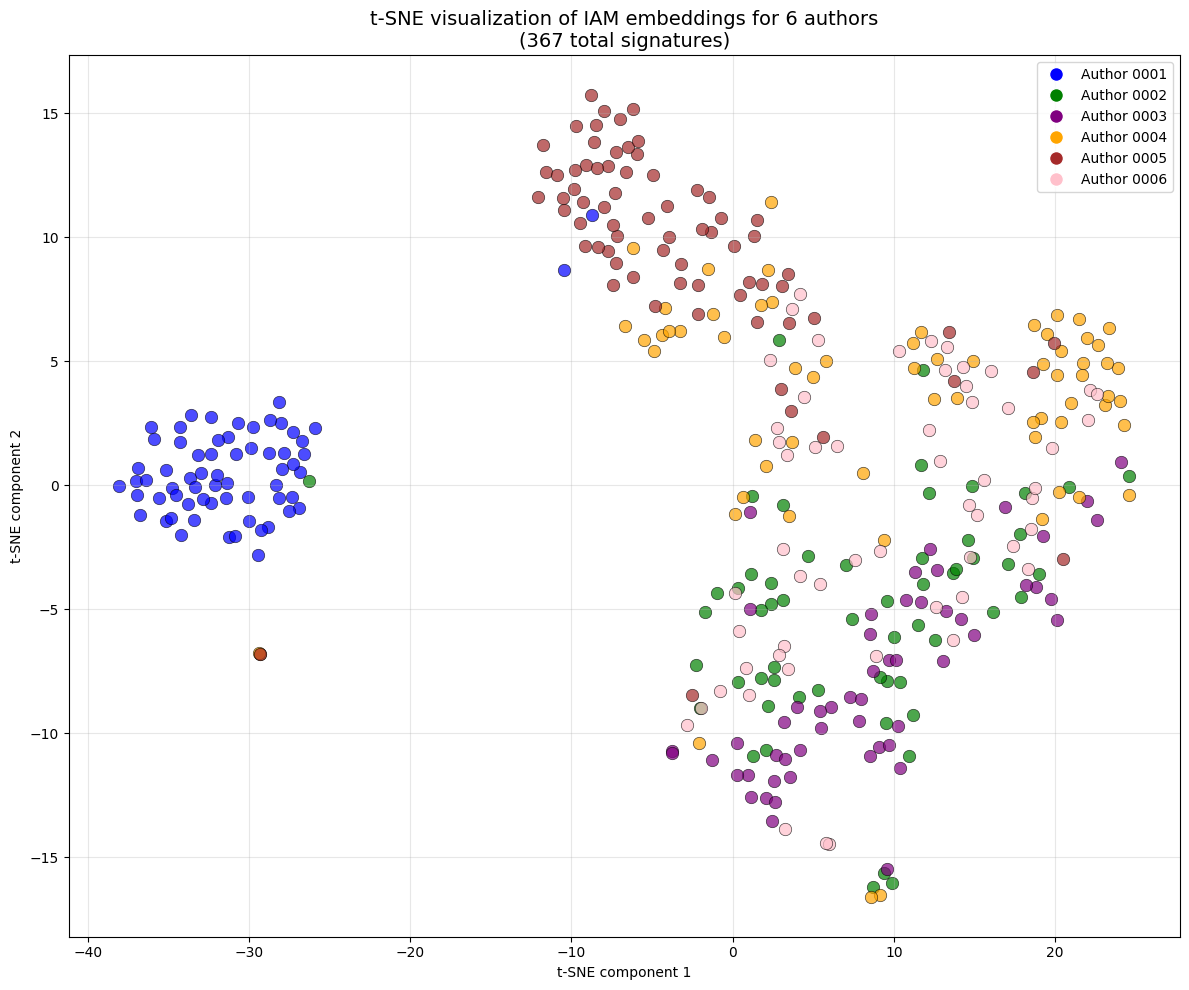


Author 0001:
  Number of images: 64
  Mean intra-class distance: 0.0900
  Std intra-class distance: 0.0502
  Min distance: 0.0030
  Max distance: 0.3427

Author 0002:
  Number of images: 57
  Mean intra-class distance: 0.0959
  Std intra-class distance: 0.0718
  Min distance: 0.0071
  Max distance: 0.4623

Author 0003:
  Number of images: 54
  Mean intra-class distance: 0.0896
  Std intra-class distance: 0.0594
  Min distance: 0.0044
  Max distance: 0.3885

Author 0004:
  Number of images: 65
  Mean intra-class distance: 0.1944
  Std intra-class distance: 0.2392
  Min distance: 0.0103
  Max distance: 1.2283

Author 0005:
  Number of images: 71
  Mean intra-class distance: 0.1461
  Std intra-class distance: 0.1601
  Min distance: 0.0121
  Max distance: 1.0816

Author 0006:
  Number of images: 56
  Mean intra-class distance: 0.0867
  Std intra-class distance: 0.0434
  Min distance: 0.0068
  Max distance: 0.2775
  Author 0001 vs Author 0002: 0.3069
  Author 0001 vs Author 0003: 0.3114
  

In [73]:
author_ids = ['0001', '0002', '0003', '0004', '0005',  '0006']
visualize_iam_embeddings(model, "/kaggle/working/cvl", author_ids, test_transform, device)